# Community ECS assessment — internal-review Colab

**Internal review version.**

This self-contained notebook defines and runs the current ECS assessment. The complete Stan program is embedded below, so the calculation does not depend on a separate local `.stan` file.

Note that the code can be simplified substantially after a few statistical decisions are decided on by the co-authors; for now, multiple options are retained, which makes the code less readable.

Running in Colab writes new output files under `/content/community_ecs_results/`.

The baseline uses a uniform-$\lambda$ prior; includes Process, Historical (PI-to-present and 21st-century Trend), and Paleoclimate (LGM and Pliocene) evidence; and uses the $N$-based energy-budget convention (which differs from the $T$-based convention in SW20). The switches below make each modeling choice easy to test directly. A few optional sensitivity tests are included.

To reproduce everything in Google Colab, use **Runtime → Run all**. The first run installs CmdStanPy, downloads the pinned prebuilt CmdStan release, and compiles this model. Later runs in the same session reuse the compiled executable.


In [5]:
import json
import os
import re
import shutil
import subprocess
import sys
import urllib.request
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde, norm, skewnorm

## Pin CmdStan so that everyone runs the same compiler version.
cmdstan_version = "2.39.0"
stan_file = Path("/tmp/community_ecs.stan")
root = Path.cwd().resolve()

try:
    import google.colab  ## type: ignore
    in_colab = True
except ImportError:
    in_colab = False

## Install CmdStanPy and the prebuilt Colab CmdStan bundle only when needed.
if in_colab:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", "cmdstanpy"
    ])

import cmdstanpy

if in_colab:
    cmdstan_dir = root / f"cmdstan-{cmdstan_version}"
    archive = Path("/tmp") / f"colab-cmdstan-{cmdstan_version}.tar.gz"
    archive_url = (
        "https://github.com/stan-dev/cmdstan/releases/download/"
        f"v{cmdstan_version}/colab-cmdstan-{cmdstan_version}.tgz"
    )
    if not cmdstan_dir.exists():
        urllib.request.urlretrieve(archive_url, archive)
        shutil.unpack_archive(str(archive), str(root))
    cmdstanpy.set_cmdstan_path(str(cmdstan_dir))

env_bin = Path(sys.executable).resolve().parent
if not in_colab:
    try:
        cmdstan_path = Path(cmdstanpy.cmdstan_path())
    except ValueError:
        env_cmdstan = env_bin / "cmdstan"
        if not env_cmdstan.exists():
            raise RuntimeError(
                "CmdStan was not found. Run this locally in the stan environment."
            )
        cmdstanpy.set_cmdstan_path(str(env_cmdstan))
        cmdstan_path = env_cmdstan
else:
    cmdstan_path = cmdstan_dir

## Locally, use the stan environment's compiler to avoid TBB ABI conflicts.
env_cxx = env_bin / "x86_64-conda-linux-gnu-g++"
cpp_options = {"CXX": str(env_cxx)} if (not in_colab and env_cxx.exists()) else {}

print("CmdStanPy:", cmdstanpy.__version__)
print("CmdStan:", cmdstan_path)
print("Stan file will be written to:", stan_file)


CmdStanPy: 1.2.1
CmdStan: /glade/derecho/scratch/vcooper/conda/envs/stan/bin/cmdstan
Stan file will be written to: /tmp/community_ecs.stan


## Embedded Stan model

The exact contents of `community_ecs.stan` are embedded here. The `%%writefile` cell writes the model to `/tmp/community_ecs.stan` before compilation.


In [6]:
%%writefile /tmp/community_ecs.stan
/*  Community ECS assessment model with data-selectable sensitivity options.

    Core lines of evidence:

      L_proc    process understanding: aggregate Gaussian on the
                total 2xCO2 feedback, lambda = -F_2xCO2/S, formed as the
                sum of component feedbacks.

      L_hist    historical warming and TOA imbalance with pattern effect:
                N = F + (lambda - dlambda)*T.
                Historical forcing is decomposed as
                F = F_CO2 + F_anthro_aerosol + F_other, with
                F_CO2 proportional to the shared F_2xCO2 parameter.

      L_trend   2006--2024 trends in temperature, effective radiative forcing,
                and TOA imbalance:
                N_trend = F_trend + (lambda - dlambda_trend)*T_trend.
                Trend forcing is decomposed as
                F_trend = F_CO2_trend + F_anthro_aerosol_trend
                          + F_other_trend, with F_CO2_trend proportional to
                          the shared F_2xCO2 parameter.
                Matching aerosol and residual-other forcing components are
                jointly assessed with their Historical counterparts. This evidence
                is included in the current community baseline (include_trend = 1).

      L_LGM     Last Glacial Maximum budget residual:
                N_LGM = F_other_LGM + f_CO2_LGM*F_2xCO2
                        + T_LGM*(lambda - dlambda_LGM).
                The signed dimensionless multiplier f_CO2_LGM is sampled,
                so the LGM CO2 forcing inherits uncertainty from both the
                shared F_2xCO2 and forcing state dependence.

      L_plio    Pliocene (mid-Piacenzian Warm Period) budget residual:
                N_plio = F_plio_CO2*(1+fCH4) + F_plio_nonGHG
                         + T_plio*(lambda - dlambda_plio),
                where F_plio_CO2 is the Meinshausen et al. (2020) CO2
                concentration-forcing ratio times the shared F_2xCO2.

    Sampled shared parameters: lambda and F_2xCO2. ECS is the
    transformed output S = -F_2xCO2/lambda.

    Model switches (all are fixed during a fit):
      lambda_prior_type        = 0: uniform-S prior (US)
                                 1: uniform-lambda prior (UL)
                                 2: reflected lognormal prior on
                                    r = -lambda

      include_process          = 0: omit the Process feedback likelihood
                                 1: include it
      use_lambda_F2x_correlation = 0: independent Gaussian assessments of
                                       lambda and F_2xCO2
                                    1: correlated bivariate Gaussian;
                                       requires include_process = 1
      include_historical       = 0: omit historical PI-to-present likelihood
                                 1: include
      include_trend            = 0: omit 21st-century Trend likelihood
                                 1: include (community baseline)
      include_lgm              = 0: omit LGM energy-budget likelihood
                                 1: include
      include_pliocene         = 0: omit Pliocene energy-budget likelihood
                                 1: include
      use_score_T              = 0: new default, evaluate model N=F+lambda*T
                                 1: rearrange each energy budget and
                                    evaluate model T=(N-F)/lambda.
    When a line is excluded, its budget/observation coupling is removed but
    its nuisance variables retain normalized, proper distributions. This
    keeps one fixed parameter interface for every switch combination. After
    marginalization, those disconnected nuisance variables contribute only a
    constant and cannot change the posterior of S, lambda, or F_2xCO2.


    --- N-based vs. T-based energy budgets -----------------------------------

    For a generic budget N = F + lambda*T, score N samples T and evaluates the
    budget-implied N against its assessment. Score T samples N, rearranges the
    same equation to T = (N-F)/lambda, and evaluates that temperature against
    its assessment. No Jacobian is added: these are deliberately different
    response-variable likelihood conventions (i.e., differeng generative 
    models), not a reparameterization of one common probability model. 
    Score T is singular at lambda=0, so a negligible interval around zero
    is assigned zero probability.

    Note for paleo: assuming N is exactly zero and evaluating F = -lambda*T
    produces essentially the same result as assuming N is Gaussian with mean
    zero and small uncertainty.

    --- prior choice ---------------------------------------------------------

    The model samples lambda directly and reports S = -F_2xCO2/lambda as a
    transformed parameter. The lambda bounds depend on F_2xCO2 so that they
    preserve the 0.05 < S < 20 K support.

    *Uniform lambda*
    Direct sampling supplies the uniform-lambda measure without an additional
    target adjustment to specify a non-uniform prior.

    *Uniform S*
    This should be used with caution; it often produces nonsensical results.
    The change of variables has
        |dS/dlambda| = F_2xCO2/lambda^2.
    Therefore the uniform-S option adds
        target += log(F_2xCO2) - 2*log(-lambda)
    to the density expressed in the sampled (lambda, F_2xCO2) coordinates.

    *lognormal lambda*
    |lambda| follows a lognormal distribution whose
    median and log-space standard deviation are supplied as data.


    --- historical/Trend forcing correlation with F_2xCO2 --------------------

    F_hist is decomposed into a CO2 component (which is proportional to
    F_2xCO2) and non-CO2 components (independent) to
    preserve the F_hist correlation with F_2xCO2. The non-CO2 term is split
    further into anthropogenic aerosol (ERFari + ERFaci) and other forcing
    so that aerosol forcing can be diagnosed and varied explicitly.

    The recent-Trend forcing uses the same construction: its CO2 component is
    proportional to F_2xCO2, while its anthropogenic aerosol and
    other forcing components are jointly distributed with their Historical
    counterparts. No covariance is assumed between different forcing components.
*/

functions {
    int value_is_finite(real x) {
        return !(is_nan(x) || is_inf(x));
    }

    // Stratospheric-adjusted CO2 forcing from Meinshausen et al. (2020),
    // evaluated at preindustrial N2O = 273 ppb. A common SARF-to-ERF factor
    // cancels when this function is used as a ratio to its own CO2 doubling.
    real meinshausen_co2_sarf(real co2_ppm) {
        real a1 = -2.4785e-7;
        real b1 = 7.5906e-4;
        real c1 = -2.1492e-3;
        real d1 = 5.2488;
        real co2_ref = 277.15;
        real n2o_pi = 273.0;
        real co2_alpha_max = co2_ref - b1 / (2 * a1);
        real alpha_prime;

        if (co2_ppm <= co2_ref)
            alpha_prime = d1;
        else if (co2_ppm < co2_alpha_max)
            alpha_prime = d1 + a1 * square(co2_ppm - co2_ref)
                             + b1 * (co2_ppm - co2_ref);
        else
            alpha_prime = d1 - square(b1) / (4 * a1);

        return (alpha_prime + c1 * sqrt(n2o_pi)) * log(co2_ppm / co2_ref);
    }
}


data {
    // Prior choice: 0 = US, 1 = UL, 2 = lognormal |lambda|.
    // This is independent of all evidence switches.
    int<lower=0, upper=2> lambda_prior_type;
    real<lower=0> lognormal_r_median;
    real<lower=0> lognormal_r_log_sigma;

    // Line-of-evidence switches.
    int<lower=0, upper=1> include_process;
    int<lower=0, upper=1> include_historical;
    int<lower=0, upper=1> include_trend;
    int<lower=0, upper=1> include_lgm;
    int<lower=0, upper=1> include_pliocene;

    // Global energy-budget response convention: 0 = score N, 1 = score T.
    int<lower=0, upper=1> use_score_T;

    // Optional dependence structure.
    int<lower=0, upper=1> use_lambda_F2x_correlation;

    // ---- Process likelihood (aggregate) ----
    // The sum of Gaussian component feedbacks.
    real          mu_lambda;
    real<lower=0> sig_lambda;

    // ---- Forcing assessment ----
    real<lower=0> erf_2x;
    real<lower=0> sig_F2xCO2;

    // Correlation of the Gaussian Process lambda and F_2xCO2 assessments.
    // Negative means larger forcing accompanies more-negative lambda.
    real<lower=-1, upper=1> rho_lambda_F2x;

    // ---- Historical evidence ----
    real          mu_T_hist;
    real<lower=0> sig_T_hist;

    real          mu_N_hist;
    real<lower=0> sig_N_hist;

    // Central historical CO2 forcing evaluated at erf_2x. Its uncertainty
    // is inherited from the shared F_2xCO2 draw.
    real          mu_F_CO2_hist;

    real          mu_F_anthro_aerosol_hist;
    real<lower=0> sig_F_anthro_aerosol_hist;

    real          mu_F_other_hist;
    real<lower=0> sig_F_other_hist;

    // Historical pattern-effect prior: skew-normal(location, scale, shape).
    // Note: shape=0 gives normal(mean=loc, sd=scale), so var=scale^2.
    real          loc_dlambda;
    real<lower=0> scale_dlambda;
    real          shape_dlambda;

    // ---- Recent Trend (2006--2024; all trends are per decade) ----
    real          mu_T_trend;
    real<lower=0> sig_T_trend;

    real          mu_N_trend;
    real<lower=0> sig_N_trend;

    // Covariance of the observed temperature and TOA-imbalance trend errors.
    real          cov_TN_trend;

    // Central CO2 forcing trend evaluated at erf_2x. Its uncertainty from
    // is inherited from the shared F_2xCO2 draw.
    real          mu_F_CO2_trend;

    real          mu_F_anthro_aerosol_trend;
    real<lower=0> sig_F_anthro_aerosol_trend;

    real          mu_F_other_trend;
    real<lower=0> sig_F_other_trend;

    // Cross-period covariance for matching non-CO2 forcing components.
    // The notebook handles the structural-error sensitivity before these
    // scalar covariance inputs are passed to Stan.
    real          cov_F_anthro_aerosol_hist_trend;
    real          cov_F_other_hist_trend;

    real          mu_dlambda_trend;
    real<lower=0> sig_dlambda_trend;

    // ---- LGM ----
    real          mu_T_LGM;
    real<lower=0> sig_T_LGM;

    real          mu_F_other_LGM;
    real<lower=0> sig_F_other_LGM;

    // Signed LGM CO2 forcing multiplier relative to F_2xCO2.
    real          mu_f_CO2_LGM;
    real<lower=0> sig_f_CO2_LGM;

    real          mu_N_LGM;
    real<lower=0> sig_N_LGM;

    real          mu_dlambda_LGM;
    real<lower=0> sig_dlambda_LGM;

    // ---- Pliocene ----
    real          mu_T_plio;
    real<lower=0> sig_T_plio;

    real          mu_CO2_plio;
    real<lower=0> sig_CO2_plio;
    real<lower=0> CO2_PI;

    real          mu_F_plio_nonGHG;
    real<lower=0> sig_F_plio_nonGHG;

    real          mu_N_plio;
    real<lower=0> sig_N_plio;

    real          mu_dlambda_plio;
    real<lower=0> sig_dlambda_plio;

    // Correlation between the LGM and Pliocene pattern effects.
    real<lower=-1, upper=1> rho_dlambda_LGM_plio;

    real          mu_fCH4;
    real<lower=0> sig_fCH4;
}
transformed data {
    real score_T_min_abs_feedback;
    matrix[2, 2] cov_lambda_F2x;
    matrix[2, 2] L_lambda_F2x;
    matrix[2, 2] cov_TN_trend_matrix;
    matrix[2, 2] L_TN_trend;
    matrix[2, 2] cov_F_anthro_aerosol_hist_trend_matrix;
    matrix[2, 2] L_F_anthro_aerosol_hist_trend;
    matrix[2, 2] cov_F_other_hist_trend_matrix;
    matrix[2, 2] L_F_other_hist_trend;

    // The score-T equations are undefined at zero effective feedback. This
    // guard is many orders of magnitude below scientifically relevant values.
    score_T_min_abs_feedback = 1e-10;

    if (lambda_prior_type == 2) {
        if (lognormal_r_median <= 0)
            reject("lognormal_r_median must be positive.");
        if (lognormal_r_log_sigma <= 0)
            reject("lognormal_r_log_sigma must be positive.");
    }

    if (use_lambda_F2x_correlation == 1) {
        if (include_process == 0)
            reject("lambda/F_2xCO2 correlation requires include_process = 1.");
        if (abs(rho_lambda_F2x) >= 1)
            reject("rho_lambda_F2x must be strictly between -1 and 1 when enabled.");

        cov_lambda_F2x[1, 1] = square(sig_F2xCO2);
        cov_lambda_F2x[2, 2] = square(sig_lambda);
        cov_lambda_F2x[1, 2] = rho_lambda_F2x * sig_F2xCO2 * sig_lambda;
        cov_lambda_F2x[2, 1] = cov_lambda_F2x[1, 2];
        L_lambda_F2x = cholesky_decompose(cov_lambda_F2x);
    } else {
        // Assigned but unused when the two assessments are independent.
        cov_lambda_F2x = diag_matrix(rep_vector(1.0, 2));
        L_lambda_F2x = diag_matrix(rep_vector(1.0, 2));
    }

    if (include_trend == 1) {
        if (abs(cov_TN_trend) >= sig_T_trend * sig_N_trend)
            reject("Trend T/N covariance matrix must be positive definite: ",
                   "abs(cov_TN_trend) must be less than ",
                   "sig_T_trend * sig_N_trend.");

        cov_TN_trend_matrix[1, 1] = square(sig_T_trend);
        cov_TN_trend_matrix[2, 2] = square(sig_N_trend);
        cov_TN_trend_matrix[1, 2] = cov_TN_trend;
        cov_TN_trend_matrix[2, 1] = cov_TN_trend;
        L_TN_trend = cholesky_decompose(cov_TN_trend_matrix);
    } else {
        // Assigned but unused; disabled options should not reject on an
        // irrelevant covariance input.
        cov_TN_trend_matrix = diag_matrix(rep_vector(1.0, 2));
        L_TN_trend = diag_matrix(rep_vector(1.0, 2));
    }

    if (include_historical == 1 && include_trend == 1) {
        if (abs(cov_F_anthro_aerosol_hist_trend)
            >= sig_F_anthro_aerosol_hist * sig_F_anthro_aerosol_trend)
            reject("Historical/Trend aerosol forcing covariance matrix must be ",
                   "positive definite.");
        if (abs(cov_F_other_hist_trend)
            >= sig_F_other_hist * sig_F_other_trend)
            reject("Historical/Trend residual-other forcing covariance matrix ",
                   "must be positive definite.");

        cov_F_anthro_aerosol_hist_trend_matrix[1, 1]
            = square(sig_F_anthro_aerosol_hist);
        cov_F_anthro_aerosol_hist_trend_matrix[2, 2]
            = square(sig_F_anthro_aerosol_trend);
        cov_F_anthro_aerosol_hist_trend_matrix[1, 2]
            = cov_F_anthro_aerosol_hist_trend;
        cov_F_anthro_aerosol_hist_trend_matrix[2, 1]
            = cov_F_anthro_aerosol_hist_trend;
        L_F_anthro_aerosol_hist_trend = cholesky_decompose(
            cov_F_anthro_aerosol_hist_trend_matrix
        );

        cov_F_other_hist_trend_matrix[1, 1] = square(sig_F_other_hist);
        cov_F_other_hist_trend_matrix[2, 2] = square(sig_F_other_trend);
        cov_F_other_hist_trend_matrix[1, 2] = cov_F_other_hist_trend;
        cov_F_other_hist_trend_matrix[2, 1] = cov_F_other_hist_trend;
        L_F_other_hist_trend = cholesky_decompose(
            cov_F_other_hist_trend_matrix
        );
    } else {
        // Assigned but unused when either line of evidence is disabled.
        cov_F_anthro_aerosol_hist_trend_matrix
            = diag_matrix(rep_vector(1.0, 2));
        L_F_anthro_aerosol_hist_trend
            = diag_matrix(rep_vector(1.0, 2));
        cov_F_other_hist_trend_matrix = diag_matrix(rep_vector(1.0, 2));
        L_F_other_hist_trend = diag_matrix(rep_vector(1.0, 2));
    }

    if (abs(rho_dlambda_LGM_plio) >= 1)
        reject("LGM/Pliocene pattern-effect correlation must be strictly ",
               "between -1 and 1.");
}
parameters {
    // The sampling space: the independent parameters that are Monte Carlo sampled
    // A tiny positive numerical floor prevents an underflowed warmup proposal
    // from collapsing the two F-dependent bounds on lamb to the same value.
    real<lower=1e-6> F_2xCO2;
    // These F-dependent bounds preserve 0.05 <= S <= 20 under
    // S = -F_2xCO2/lamb and enforce the physical lamb < 0 domain.
    real<lower=-F_2xCO2 / 0.05, upper=-F_2xCO2 / 20> lamb;

    // historical nuisance parameters
    real F_anthro_aerosol_hist;
    real F_other_hist;
    real T_hist;
    real N_hist_scoreT;
    real dlambda;

    // LGM nuisance
    real T_LGM;
    real N_LGM_scoreT;
    real F_other_LGM;
    real f_CO2_LGM;
    real dlambda_LGM;

    // Pliocene nuisance
    real T_plio;
    real N_plio_scoreT;
    real <lower=0> CO2_plio;
    real F_plio_nonGHG;
    real dlambda_plio;
    real fCH4;
    // recent-Trend nuisance parameters
    real F_anthro_aerosol_trend;
    real F_other_trend;
    real T_trend;
    real N_trend_scoreT;
    real dlambda_trend;
}
transformed parameters{

    // These are dependent parameters that are a function of the independent parameters
    real S;        // equilibrium climate sensitivity
    real F_CO2_hist;
    real F_hist;
    real N_hist;
    real T_hist_scoreT;
    real F_CO2_trend;
    real F_trend;
    real N_trend;
    real T_trend_scoreT;
    real F_CO2_LGM;
    real N_LGM;
    real T_LGM_scoreT;
    real f_CO2_plio;
    real F_plio_CO2;
    real N_plio;
    real T_plio_scoreT;

    // parameter formulas

    // ECS derived from the directly sampled feedback parameter.
    S = -F_2xCO2 / lamb;

    // Historical CO2 forcing shares the same uncertainty
    // as F_2xCO2. At F_2xCO2 = erf_2x its central value is mu_F_CO2_hist.
    F_CO2_hist = mu_F_CO2_hist * F_2xCO2 / erf_2x;
    F_hist = F_CO2_hist + F_anthro_aerosol_hist + F_other_hist;

    // coupling equations
    N_hist  = F_hist + (lamb - dlambda) * T_hist;
    if (abs(lamb - dlambda) > score_T_min_abs_feedback)
        T_hist_scoreT = (N_hist_scoreT - F_hist) / (lamb - dlambda);
    else
        T_hist_scoreT = 0;

    // The Trend CO2 forcing shares the same uncertainty as F_2xCO2.
    // Aerosol and residual-other forcing are separate nuisances.
    F_CO2_trend = mu_F_CO2_trend * F_2xCO2 / erf_2x;
    F_trend = F_CO2_trend + F_anthro_aerosol_trend + F_other_trend;

    // 2006--2024 trend energy budget.
    N_trend = F_trend + (lamb - dlambda_trend) * T_trend;
    if (abs(lamb - dlambda_trend) > score_T_min_abs_feedback)
        T_trend_scoreT = (N_trend_scoreT - F_trend)
                         / (lamb - dlambda_trend);
    else
        T_trend_scoreT = 0;

    F_CO2_LGM = f_CO2_LGM * F_2xCO2;
    N_LGM = F_other_LGM + F_CO2_LGM + (lamb - dlambda_LGM) * T_LGM;
    if (abs(lamb - dlambda_LGM) > score_T_min_abs_feedback)
        T_LGM_scoreT = (N_LGM_scoreT - F_other_LGM - F_CO2_LGM)
                       / (lamb - dlambda_LGM);
    else
        T_LGM_scoreT = 0;

    f_CO2_plio = (meinshausen_co2_sarf(CO2_plio)
                  - meinshausen_co2_sarf(CO2_PI))
                 / (meinshausen_co2_sarf(2 * CO2_PI)
                    - meinshausen_co2_sarf(CO2_PI));
    F_plio_CO2 = f_CO2_plio * F_2xCO2;
    N_plio = F_plio_CO2*(1+fCH4) + F_plio_nonGHG + (lamb - dlambda_plio)*T_plio;
    if (abs(lamb - dlambda_plio) > score_T_min_abs_feedback)
        T_plio_scoreT = (N_plio_scoreT - F_plio_CO2 * (1 + fCH4)
                         - F_plio_nonGHG)
                        / (lamb - dlambda_plio);
    else
        T_plio_scoreT = 0;
}
model {
    vector[2] dlambda_pair;
    vector[2] mu_dlambda_pair;
    matrix[2, 2] cov_dlambda_pair;

    // Shared forcing and optional Process likelihood. The correlated branch
    // preserves both Gaussian marginals and changes only their dependence.
    if (include_process == 1) {
        if (use_lambda_F2x_correlation == 1) {
            vector[2] lambda_F2x_pair;
            vector[2] mu_lambda_F2x_pair;

            lambda_F2x_pair[1] = F_2xCO2;
            lambda_F2x_pair[2] = lamb;
            mu_lambda_F2x_pair[1] = erf_2x;
            mu_lambda_F2x_pair[2] = mu_lambda;
            lambda_F2x_pair ~ multi_normal_cholesky(
                mu_lambda_F2x_pair, L_lambda_F2x
            );
        } else {
            F_2xCO2 ~ normal(erf_2x, sig_F2xCO2);
            lamb ~ normal(mu_lambda, sig_lambda);
        }
    } else {
        // F_2xCO2 retains its assessment when Process evidence is omitted.
        F_2xCO2 ~ normal(erf_2x, sig_F2xCO2);
    }

    // Historical/Trend component-forcing priors. When both lines are enabled,
    // matching components are assessed jointly across periods. Otherwise all
    // four nuisance parameters retain their normalized marginal priors.
    if (include_historical == 1 && include_trend == 1) {
        vector[2] F_anthro_aerosol_hist_trend_pair;
        vector[2] mu_F_anthro_aerosol_hist_trend_pair;
        vector[2] F_other_hist_trend_pair;
        vector[2] mu_F_other_hist_trend_pair;

        F_anthro_aerosol_hist_trend_pair[1] = F_anthro_aerosol_hist;
        F_anthro_aerosol_hist_trend_pair[2] = F_anthro_aerosol_trend;
        mu_F_anthro_aerosol_hist_trend_pair[1]
            = mu_F_anthro_aerosol_hist;
        mu_F_anthro_aerosol_hist_trend_pair[2]
            = mu_F_anthro_aerosol_trend;
        F_anthro_aerosol_hist_trend_pair ~ multi_normal_cholesky(
            mu_F_anthro_aerosol_hist_trend_pair,
            L_F_anthro_aerosol_hist_trend
        );

        F_other_hist_trend_pair[1] = F_other_hist;
        F_other_hist_trend_pair[2] = F_other_trend;
        mu_F_other_hist_trend_pair[1] = mu_F_other_hist;
        mu_F_other_hist_trend_pair[2] = mu_F_other_trend;
        F_other_hist_trend_pair ~ multi_normal_cholesky(
            mu_F_other_hist_trend_pair, L_F_other_hist_trend
        );
    } else {
        F_anthro_aerosol_hist ~ normal(
            mu_F_anthro_aerosol_hist, sig_F_anthro_aerosol_hist
        );
        F_anthro_aerosol_trend ~ normal(
            mu_F_anthro_aerosol_trend, sig_F_anthro_aerosol_trend
        );
        F_other_hist ~ normal(mu_F_other_hist, sig_F_other_hist);
        F_other_trend ~ normal(mu_F_other_trend, sig_F_other_trend);
    }

    // Historical
    T_hist  ~ normal(mu_T_hist , sig_T_hist);
    N_hist_scoreT ~ normal(mu_N_hist, sig_N_hist);
    if (include_historical == 1) {
        if (use_score_T == 1) {
            if (abs(lamb - dlambda) > score_T_min_abs_feedback
                && value_is_finite(T_hist_scoreT))
                T_hist_scoreT ~ normal(mu_T_hist, sig_T_hist);
            else
                target += negative_infinity();
        } else {
            if (value_is_finite(N_hist))
                N_hist ~ normal(mu_N_hist, sig_N_hist);
            else
                target += negative_infinity();
        }
    }

    // 21st-century Trend
    // When Trend is disabled, nuisance parameters
    // remain independent of all shared ECS parameters and therefore do
    // not alter their posterior; the corresponding output columns are inert.
    dlambda_trend ~ normal(mu_dlambda_trend, sig_dlambda_trend);
    if (include_trend == 1) {
        // Score the observed T/N pair in the selected orientation. The same
        // covariance matrix is used for both response-variable conventions.
        vector[2] trend_pair;
        vector[2] mu_trend_pair;

        mu_trend_pair[1] = mu_T_trend;
        mu_trend_pair[2] = mu_N_trend;

        if (use_score_T == 1) {
            // T_trend is inactive in this branch but retains a proper prior.
            T_trend ~ normal(mu_T_trend, sig_T_trend);
            trend_pair[1] = T_trend_scoreT;
            trend_pair[2] = N_trend_scoreT;
            if (abs(lamb - dlambda_trend) > score_T_min_abs_feedback
                && value_is_finite(T_trend_scoreT)
                && value_is_finite(N_trend_scoreT))
                trend_pair ~ multi_normal_cholesky(
                    mu_trend_pair, L_TN_trend
                );
            else
                target += negative_infinity();
        } else {
            // N_trend_scoreT is inactive in this branch but remains proper.
            N_trend_scoreT ~ normal(mu_N_trend, sig_N_trend);
            trend_pair[1] = T_trend;
            trend_pair[2] = N_trend;
            if (value_is_finite(T_trend) && value_is_finite(N_trend))
                trend_pair ~ multi_normal_cholesky(
                    mu_trend_pair, L_TN_trend
                );
            else
                target += negative_infinity();
        }
    } else {
        T_trend ~ normal(mu_T_trend, sig_T_trend);
        N_trend_scoreT ~ normal(mu_N_trend, sig_N_trend);
    }

    // LGM
    T_LGM       ~ normal(mu_T_LGM, sig_T_LGM);
    N_LGM_scoreT ~ normal(mu_N_LGM, sig_N_LGM);
    F_other_LGM ~ normal(mu_F_other_LGM, sig_F_other_LGM);
    f_CO2_LGM   ~ normal(mu_f_CO2_LGM, sig_f_CO2_LGM);
    if (include_lgm == 1) {
        if (use_score_T == 1) {
            if (abs(lamb - dlambda_LGM) > score_T_min_abs_feedback
                && value_is_finite(T_LGM_scoreT))
                T_LGM_scoreT ~ normal(mu_T_LGM, sig_T_LGM);
            else
                target += negative_infinity();
        } else {
            if (value_is_finite(N_LGM))
                N_LGM ~ normal(mu_N_LGM, sig_N_LGM);
            else
                target += negative_infinity();
        }
    }

    // Pliocene
    T_plio        ~ normal(mu_T_plio, sig_T_plio);
    N_plio_scoreT ~ normal(mu_N_plio, sig_N_plio);
    CO2_plio      ~ normal(mu_CO2_plio, sig_CO2_plio);
    fCH4          ~ normal(mu_fCH4, sig_fCH4);
    F_plio_nonGHG ~ normal(mu_F_plio_nonGHG, sig_F_plio_nonGHG);
    if (include_pliocene == 1) {
        if (use_score_T == 1) {
            if (abs(lamb - dlambda_plio) > score_T_min_abs_feedback
                && value_is_finite(T_plio_scoreT))
                T_plio_scoreT ~ normal(mu_T_plio, sig_T_plio);
            else
                target += negative_infinity();
        } else {
            if (value_is_finite(N_plio))
                N_plio ~ normal(mu_N_plio, sig_N_plio);
            else
                target += negative_infinity();
        }
    }
    // Historical pattern effect is independent of the correlated paleo pair.
    dlambda ~ skew_normal(loc_dlambda, scale_dlambda, shape_dlambda);

    dlambda_pair[1] = dlambda_LGM;
    dlambda_pair[2] = dlambda_plio;
    mu_dlambda_pair[1] = mu_dlambda_LGM;
    mu_dlambda_pair[2] = mu_dlambda_plio;
    cov_dlambda_pair[1, 1] = square(sig_dlambda_LGM);
    cov_dlambda_pair[2, 2] = square(sig_dlambda_plio);
    cov_dlambda_pair[1, 2] = rho_dlambda_LGM_plio
                             * sig_dlambda_LGM * sig_dlambda_plio;
    cov_dlambda_pair[2, 1] = cov_dlambda_pair[1, 2];

    dlambda_pair ~ multi_normal(mu_dlambda_pair, cov_dlambda_pair);

    // Direct sampling gives the uniform-lambda measure by default. Convert it
    // to uniform S when US is requested, or add the reflected lognormal
    // density on the positive damping r = -lambda.
    if (lambda_prior_type == 0)
        target += log(F_2xCO2) - 2 * log(-lamb);
    else if (lambda_prior_type == 2)
        target += lognormal_lpdf(
            -lamb | log(lognormal_r_median), lognormal_r_log_sigma
        );
}


Overwriting /tmp/community_ecs.stan


## Assessed inputs

The assessed central values and 1-sigma uncertainties are kept together here. Every input remains in the dictionary even when a line of evidence is disabled because the unified Stan model uses one fixed data interface.

**Run all cells after opening this revision.** Cached results from the previous full run are retained for reference, but they do not automatically reflect the revised process assessment, forcing covariance, or prior interface.

In [7]:
## Process feedback components.
## Component means and standard deviations use the latest cloud assessment.
## Only the aggregate process lambda is passed to the Stan model.
marine_lowcloud_mu = 0.30975
marine_lowcloud_sig = 0.211013
highcloud_amt_optdepth_mu = 0.01350
highcloud_amt_optdepth_sig = 0.114829
highcloud_alt_mu = 0.24180
highcloud_alt_sig = 0.125454
landcloud_mu = 0.08
landcloud_sig = 0.08
unassessed_cloud_mu = 0.0
unassessed_cloud_sig = 0.10

## Means and variances add under the assumed component independence.
cloud_total_mu = (
    marine_lowcloud_mu + highcloud_amt_optdepth_mu
    + highcloud_alt_mu + landcloud_mu + unassessed_cloud_mu
)
cloud_total_sig = np.sqrt(
    marine_lowcloud_sig**2 + highcloud_amt_optdepth_sig**2
    + highcloud_alt_sig**2 + landcloud_sig**2
    + unassessed_cloud_sig**2
)

## Non-cloud assessed components.
planck_mu, planck_sig = -3.23, 0.11
lrwv_mu, lrwv_sig = 1.27, 0.18
surface_albedo_mu, surface_albedo_sig = 0.39, 0.15
noncloud_total_mu = planck_mu + lrwv_mu + surface_albedo_mu
noncloud_total_sig = np.sqrt(
    planck_sig**2 + lrwv_sig**2 + surface_albedo_sig**2
)
unassessed_noncloud_mu, unassessed_noncloud_sig = 0.0, 0.16
process_lamb_mu = (
    cloud_total_mu + noncloud_total_mu + unassessed_noncloud_mu
)
process_lamb_sig = np.sqrt(
    cloud_total_sig**2 + noncloud_total_sig**2
    + unassessed_noncloud_sig**2
)
print(
    f"Cloud: {cloud_total_mu:.3f} ± {cloud_total_sig:.3f}; "
    f"total process: {process_lamb_mu:.4f} ± {process_lamb_sig:.4f} "
    "W m-2 K-1"
)

## Define common inputs once and reuse them in the data dictionary.
erf_2x = 3.93
sig_erf_2x = 0.29
co2_pi = 284.7

## lognormal prior on the positive damping r = -lambda, i.e. |lambda|
lognormal_r_median = np.exp(3.0) #1.0
lognormal_r_log_sigma = np.sqrt(3.) #0.8

## Skew-normal parameters for the historical pattern effect.
## The default inputs give a -0.62 median pattern effect.
## Set shape=0 to obtain normal(mean=loc, sd=scale).
hist_dlambda_shape = -3.7573
hist_dlambda_loc = 0.9726
hist_dlambda_scale = 0.5195

## Correlation between the two paleo pattern effects.
## Calculated from the paired model-pattern grids using the preferred
## 5-year-coarsened abrupt-CO2 reference feedbacks.
rho_LGM_plio = 0.43

## ----- OPTIONAL -----
## Optional Process-lambda / ERF2x correlation. Negative means that a
## larger (more-positive) F_2xCO2 accompanies a more-negative lambda.
rho_lambda_F2x = 0.0  ## Set to -0.50 for the assessed anticorrelation sensitivity.

## 2006--2024 ERF-trend decomposition; anthropogenic aerosol is ARI+ACI.
## The aerosol trend has paired-ensemble and additional structural spreads.
## Both covariance choices retain the structural contribution to variance.
## CO2 uncertainty is inherited from F2x and is not added independently.
mu_F_CO2_trend = 0.329
mu_F_anthro_aerosol_trend = 0.200
sig_F_anthro_aerosol_hist = 0.342
sig_F_anthro_aerosol_trend_ensemble = 0.143
sig_F_anthro_aerosol_trend_structural = 0.10
rho_F_anthro_aerosol_struct_hist = -0.5043638097
sig_F_anthro_aerosol_trend = np.sqrt(
    sig_F_anthro_aerosol_trend_ensemble**2
    + sig_F_anthro_aerosol_trend_structural**2
)
mu_F_other_trend = 0.150
sig_F_other_trend = 0.016

## Paired IGCC covariance between the historical forcing change and the
## 2006--2024 trend. Choose whether the additional structural aerosol error
## contributes to covariance. Change this one setting to compare assumptions.
cov_F_anthro_aerosol_hist_trend_ensemble = -0.0247083552
aerosol_structural_covariance_mode = "correlated"  ## or "independent"
cov_F_anthro_aerosol_hist_trend_options = {
    "independent": cov_F_anthro_aerosol_hist_trend_ensemble,
    "correlated": (
        cov_F_anthro_aerosol_hist_trend_ensemble
        + rho_F_anthro_aerosol_struct_hist
        * sig_F_anthro_aerosol_hist
        * sig_F_anthro_aerosol_trend_structural
    ),
}
cov_F_anthro_aerosol_hist_trend = (
    cov_F_anthro_aerosol_hist_trend_options[
        aerosol_structural_covariance_mode
    ]
)
cov_F_other_hist_trend = 0.00108444987

base_inputs = {
    ## Shared forcing
    "erf_2x": erf_2x,
    "sig_F2xCO2": sig_erf_2x,
    "rho_lambda_F2x": rho_lambda_F2x,

    ## Reflected-lognormal lambda-prior parameters
    "lognormal_r_median": lognormal_r_median,
    "lognormal_r_log_sigma": lognormal_r_log_sigma,

    ## Process evidence
    "mu_lambda": process_lamb_mu,
    "sig_lambda": process_lamb_sig,

    ## Historical evidence
    "mu_T_hist": 1.09,
    "sig_T_hist": np.sqrt(0.08**2 + 0.07**2), ## observational + internal variability
    "mu_N_hist": 0.81,
    "sig_N_hist": 0.20,
    "mu_F_CO2_hist": 1.80,
    "mu_F_anthro_aerosol_hist": -0.970,
    "sig_F_anthro_aerosol_hist": sig_F_anthro_aerosol_hist,
    "mu_F_other_hist": 1.820,
    "sig_F_other_hist": 0.175,
    "shape_dlambda": hist_dlambda_shape,
    "loc_dlambda": hist_dlambda_loc,
    "scale_dlambda": hist_dlambda_scale,

    ## 2006--2024 Trend evidence (per decade)
    "mu_F_CO2_trend": mu_F_CO2_trend,
    "mu_F_anthro_aerosol_trend": mu_F_anthro_aerosol_trend,
    "sig_F_anthro_aerosol_trend": sig_F_anthro_aerosol_trend,
    "mu_F_other_trend": mu_F_other_trend,
    "sig_F_other_trend": sig_F_other_trend,
    "cov_F_anthro_aerosol_hist_trend": (
        cov_F_anthro_aerosol_hist_trend
    ),
    "cov_F_other_hist_trend": cov_F_other_hist_trend,
    "mu_T_trend": 0.297,
    "sig_T_trend": 0.071,
    "mu_N_trend": 0.452,
    "sig_N_trend": 0.161,
    "cov_TN_trend": -0.00297,
    "mu_dlambda_trend": 0.0,
    "sig_dlambda_trend": 0.30,

    ## LGM evidence
    "mu_T_LGM": -6.0,
    "sig_T_LGM": 0.9,
    "mu_F_other_LGM": -4.45,
    "sig_F_other_LGM": 1.86,
    "mu_f_CO2_LGM": -0.55,
    "sig_f_CO2_LGM": 0.04,
    "mu_N_LGM": -0.03,
    "sig_N_LGM": 0.03,
    # "sig_N_LGM": 0.1 / 1.645,
    "mu_dlambda_LGM": -0.32, #-0.42,
    "sig_dlambda_LGM": 0.30,  #0.34,

    ## mPWP evidence
    "mu_T_plio": 3.9,
    "sig_T_plio": 0.9,
    "mu_CO2_plio": 391.,
    "sig_CO2_plio": 21., 
    "CO2_PI": co2_pi,
    "mu_F_plio_nonGHG": 1.59,  ## PlioMIP2 boundary conditions for KM5c
    "sig_F_plio_nonGHG": 0.85,
    "mu_N_plio": 0.0,
    "sig_N_plio": 0.01,# / 1.645,
    "mu_dlambda_plio": -0.35,
    "sig_dlambda_plio": 0.37,
    "mu_fCH4": 0.43,
    "sig_fCH4": 0.08,

    ## Paleo pattern-effect correlation
    "rho_dlambda_LGM_plio": rho_LGM_plio,
}

print(f"{len(base_inputs)} assessed inputs defined")

Cloud: 0.645 ± 0.300; total process: -0.9249 ± 0.4271 W m-2 K-1
57 assessed inputs defined


## Model switches

Most settings are binary. `lambda_prior_type` is categorical: `0` selects uniform $S$, `1` selects uniform $\lambda$, and `2` selects a reflected lognormal on the positive damping $r=-\lambda$. The `lambda_prior_types` names below avoid needing to remember those integers. The prior choice remains available whether Process evidence is on or off. Setting `use_lambda_F2x_correlation=1` applies `rho_lambda_F2x` through the joint Gaussian Process/forcing assessment and therefore requires Process evidence.

The baseline uses a uniform-$\lambda$ prior; includes Process, Historical, Trend, LGM, and Pliocene; and uses the $N$-based energy-budget equations. Set `use_score_T=1` to rearrange every enabled energy-budget equation and score $T$ instead. When Historical and Trend are both enabled, matching aerosol and residual-other forcing components use the cross-period covariances in `base_inputs`; no cross-period covariance is yet applied to $T$, $N$, or pattern effects. `aerosol_structural_covariance_mode` selects whether the additional aerosol-trend structural error is independent of historical forcing or contributes covariance using the assessed aerosol anti-correlation.

> **Interim-review note.** The Stan code can be shortened by analytically marginalizing the latent $T$ and $N$ variables. For $\beta=\lambda-\Delta\lambda$, the repeated branches can be replaced by
> $$
> \mu_N \sim \mathcal{N}\!\left(F+\beta\mu_T,\sqrt{\sigma_N^2+\beta^2\sigma_T^2-2\beta\,\mathrm{Cov}(T,N)}\right),
> $$
> with `target += log(abs(beta))` added for the $T$-based convention. The separate $N$-based and $T$-based branches are retained here for clarity during interim review.


In [8]:
lambda_prior_types = {
    "uniform_s": 0,
    "uniform_lambda": 1,
    "lognormal_lambda": 2,
}

switch_names = (
    "lambda_prior_type",
    "include_process",
    "use_lambda_F2x_correlation",
    "include_historical",
    "include_trend",
    "include_lgm",
    "include_pliocene",
    "use_score_T",
)

binary_switch_names = tuple(
    name for name in switch_names if name != "lambda_prior_type"
)

baseline_switches = {
    "lambda_prior_type": lambda_prior_types["uniform_lambda"],
    "include_process": 1,
    "use_lambda_F2x_correlation": 0,
    "include_historical": 1,
    "include_trend": 1,
    "include_lgm": 1,
    "include_pliocene": 1,
    "use_score_T": 0,
}

def _validate_data(data):
    expected = set(base_inputs) | set(switch_names)
    missing = expected - set(data)
    extra = set(data) - expected
    if missing or extra:
        raise ValueError(f"Data keys differ from expected; missing={missing}, extra={extra}")

    bad_switches = {
        k: data[k] for k in binary_switch_names if data[k] not in (0, 1)
    }
    if bad_switches:
        raise ValueError(f"Binary switches must be 0 or 1: {bad_switches}")

    if data["lambda_prior_type"] not in lambda_prior_types.values():
        raise ValueError(
            f"lambda_prior_type must be one of {lambda_prior_types}: "
            f"got {data['lambda_prior_type']}"
        )
    if data["lognormal_r_median"] <= 0:
        raise ValueError("lognormal_r_median must be positive")
    if data["lognormal_r_log_sigma"] <= 0:
        raise ValueError("lognormal_r_log_sigma must be positive")

    if data["use_lambda_F2x_correlation"]:
        if not data["include_process"]:
            raise ValueError(
                "lambda/F_2xCO2 correlation requires include_process=1"
            )
        if not -1 < data["rho_lambda_F2x"] < 1:
            raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    if data["include_trend"]:
        trend_cov = np.array([
            [data["sig_T_trend"]**2, data["cov_TN_trend"]],
            [data["cov_TN_trend"], data["sig_N_trend"]**2],
        ])
        np.linalg.cholesky(trend_cov)

    if data["include_historical"] and data["include_trend"]:
        aerosol_forcing_cov = np.array([
            [
                data["sig_F_anthro_aerosol_hist"]**2,
                data["cov_F_anthro_aerosol_hist_trend"],
            ],
            [
                data["cov_F_anthro_aerosol_hist_trend"],
                data["sig_F_anthro_aerosol_trend"]**2,
            ],
        ])
        other_forcing_cov = np.array([
            [
                data["sig_F_other_hist"]**2,
                data["cov_F_other_hist_trend"],
            ],
            [
                data["cov_F_other_hist_trend"],
                data["sig_F_other_trend"]**2,
            ],
        ])
        np.linalg.cholesky(aerosol_forcing_cov)
        np.linalg.cholesky(other_forcing_cov)

    if not -1 < data["rho_dlambda_LGM_plio"] < 1:
        raise ValueError("rho_dlambda_LGM_plio must lie strictly between -1 and 1")


def make_data(switch_updates=None, input_updates=None):
    """Build and validate one complete community_ecs.stan data dictionary."""
    switches = dict(baseline_switches)
    switch_updates = {} if switch_updates is None else dict(switch_updates)
    input_updates = {} if input_updates is None else dict(input_updates)

    unknown_switches = set(switch_updates) - set(switch_names)
    unknown_inputs = set(input_updates) - set(base_inputs)
    if unknown_switches:
        raise KeyError(f"Unknown model switches: {sorted(unknown_switches)}")
    if unknown_inputs:
        raise KeyError(f"Unknown assessed inputs: {sorted(unknown_inputs)}")

    switches.update(switch_updates)
    inputs = dict(base_inputs)
    inputs.update(input_updates)
    data = dict(inputs, **switches)
    _validate_data(data)
    return data


baseline_data = make_data()
pd.Series(baseline_switches, name="baseline").to_frame()

,baseline
lambda_prior_type,1
include_process,1
use_lambda_F2x_correlation,0
include_historical,1
include_trend,1
include_lgm,1
include_pliocene,1
use_score_T,0


## Initialization and sampling controls

The model samples `lamb` directly and calculates `S` as a transformed parameter, so initial values contain `lamb`, not `S`. Proper initial values are retained for both score conventions because the unified interface keeps nuisance parameters even when a branch is inactive. These defaults are suitable for comparisons; increase `iter_sampling` for final tail estimates.


In [13]:
def make_init(data, ecs_initial=4.0, init_updates=None):
    init = {
        "F_2xCO2": data["erf_2x"],
        "lamb": -data["erf_2x"] / ecs_initial,
        "F_anthro_aerosol_hist": data["mu_F_anthro_aerosol_hist"],
        "F_other_hist": data["mu_F_other_hist"],
        "T_hist": data["mu_T_hist"],
        "N_hist_scoreT": data["mu_N_hist"],
        "dlambda": skewnorm.ppf(
            0.5, a=data["shape_dlambda"],
            loc=data["loc_dlambda"], scale=data["scale_dlambda"],
        ),
        "T_LGM": data["mu_T_LGM"],
        "N_LGM_scoreT": data["mu_N_LGM"],
        "F_other_LGM": data["mu_F_other_LGM"],
        "f_CO2_LGM": data["mu_f_CO2_LGM"],
        "dlambda_LGM": data["mu_dlambda_LGM"],
        "T_plio": data["mu_T_plio"],
        "N_plio_scoreT": data["mu_N_plio"],
        "CO2_plio": data["mu_CO2_plio"],
        "F_plio_nonGHG": data["mu_F_plio_nonGHG"],
        "dlambda_plio": data["mu_dlambda_plio"],
        "fCH4": data["mu_fCH4"],
        "F_anthro_aerosol_trend": data["mu_F_anthro_aerosol_trend"],
        "F_other_trend": data["mu_F_other_trend"],
        "T_trend": data["mu_T_trend"],
        "N_trend_scoreT": data["mu_N_trend"],
        "dlambda_trend": data["mu_dlambda_trend"],
    }
    if init_updates:
        unknown = set(init_updates) - set(init)
        if unknown:
            raise KeyError(f"Unknown initial-value parameters: {sorted(unknown)}")
        init.update(init_updates)
    return init


sampling_defaults = {
    "chains": 4,
    "parallel_chains": 4,
    ## Quick comparison defaults; increase these for final tail estimates.
    "iter_warmup": 1_000,
    "iter_sampling": 5_000,
    "adapt_delta": 0.95,
    "max_treedepth": 12,
    "seed": 20250812,
    "show_progress": True,
    "show_console": False,
    "refresh": 500,
}

make_init(baseline_data)

{'F_2xCO2': 3.93,
 'lamb': -0.9825,
 'F_anthro_aerosol_hist': -0.97,
 'F_other_hist': 1.82,
 'T_hist': 1.09,
 'N_hist_scoreT': 0.81,
 'dlambda': 0.6224390559414669,
 'T_LGM': -6.0,
 'N_LGM_scoreT': -0.03,
 'F_other_LGM': -4.45,
 'f_CO2_LGM': -0.55,
 'dlambda_LGM': -0.32,
 'T_plio': 3.9,
 'N_plio_scoreT': 0.0,
 'CO2_plio': 391.0,
 'F_plio_nonGHG': 1.59,
 'dlambda_plio': -0.35,
 'fCH4': 0.43,
 'F_anthro_aerosol_trend': 0.2,
 'F_other_trend': 0.15,
 'T_trend': 0.297,
 'N_trend_scoreT': 0.452,
 'dlambda_trend': 0.0}

## Compile the model

Compile the embedded Stan program once. CmdStanPy reuses the executable for every scenario in this session.


In [10]:
community_model = cmdstanpy.CmdStanModel(
    stan_file=str(stan_file), cpp_options=cpp_options
)
print("Compiled model:", community_model.exe_file)

09:55:13 - cmdstanpy - INFO - compiling stan file /tmp/community_ecs.stan to exe file /tmp/community_ecs
09:56:58 - cmdstanpy - INFO - compiled model executable: /tmp/community_ecs


Compiled model: /tmp/community_ecs


## Reusable scenario runner

Each completed fit is stored in `results[name]`. Its CmdStan CSV files, exact data, metadata, and summary are also written beneath `community_ecs_results/`. These files are temporary in a standard Colab session unless they are downloaded or Google Drive is mounted.


In [11]:
results_root = root / "community_ecs_results"
results = {}


def run_scenario(
    name, *, switch_updates=None, input_updates=None,
    sampling_updates=None, init_updates=None, ecs_initial=4.0,
):
    """Run one named scenario and save its fit, inputs, and summaries."""
    if not re.fullmatch(r"[A-Za-z0-9_.-]+", name):
        raise ValueError("name may contain only letters, numbers, '.', '_' and '-'")

    data = make_data(switch_updates=switch_updates, input_updates=input_updates)
    inits = make_init(data, ecs_initial=ecs_initial, init_updates=init_updates)
    sampling = dict(sampling_defaults)
    if sampling_updates:
        sampling.update(sampling_updates)

    stamp = datetime.now().strftime("%Y%m%dT%H%M%S_%f")
    run_dir = results_root / f"{name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=False)
    cmdstanpy.write_stan_json(str(run_dir / "data.json"), data)

    metadata = {
        "name": name,
        "created": stamp,
        "stan_file": str(stan_file),
        "switches": {key: data[key] for key in switch_names},
        "sampling": sampling,
    }
    with (run_dir / "metadata.json").open("w") as handle:
        json.dump(metadata, handle, indent=2)

    print(f"Running {name!r}")
    print("Switches:", metadata["switches"])
    fit = community_model.sample(
        data=data, inits=inits, output_dir=str(run_dir), **sampling
    )
    summary = fit.summary()
    summary.to_csv(run_dir / "summary.csv")

    entry = {
        "fit": fit,
        "data": data,
        "inits": inits,
        "switches": metadata["switches"],
        "sampling": sampling,
        "summary": summary,
        "S": fit.stan_variable("S"),
        "lamb": fit.stan_variable("lamb"),
        "output_dir": run_dir,
    }
    results[name] = entry

    divergences = int(np.sum(fit.method_variables()["divergent__"]))
    s_quantiles = np.quantile(entry["S"], [0.05, 0.17, 0.50, 0.83, 0.95])
    print("S quantiles [5, 17, 50, 83, 95]%:", np.round(s_quantiles, 3))
    print("Divergences:", divergences)
    print("Saved to:", run_dir)
    return entry


def compare_scenarios(names=None):
    """Return an ECS comparison table for completed scenarios."""
    names = list(results) if names is None else list(names)
    rows = []
    for name in names:
        entry = results[name]
        s = entry["S"]
        q = np.quantile(s, [0.05, 0.17, 0.50, 0.83, 0.95])
        fit = entry["fit"]
        rows.append({
            "scenario": name,
            "mean": np.mean(s),
            "sd": np.std(s, ddof=1),
            "p05": q[0], "p17": q[1], "p50": q[2],
            "p83": q[3], "p95": q[4],
            "divergences": int(np.sum(fit.method_variables()["divergent__"])),
            "R_hat_S": entry["summary"].loc["S", "R_hat"],
            "ESS_bulk_S": entry["summary"].loc["S", "ESS_bulk"],
        })
    return pd.DataFrame(rows).set_index("scenario").round(3)

## Baseline calculation

Baseline settings: uniform $\lambda$ prior; Process, Joint Historical (PItoPresent + Trend), Joint Paleo (LGM + Pliocene); $N$-based energy budgets.


In [15]:
## increase iter_sampling to higher values to reduce sampling error
baseline = run_scenario("baseline")##, sampling_updates={'iter_sampling': 80_000})
compare_scenarios()

10:43:08 - cmdstanpy - INFO - CmdStan start processing


Running 'baseline'
Switches: {'lambda_prior_type': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_historical': 1, 'include_trend': 1, 'include_lgm': 1, 'include_pliocene': 1, 'use_score_T': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:45:00 - cmdstanpy - INFO - CmdStan done processing.



S quantiles [5, 17, 50, 83, 95]%: [2.563 2.885 3.46  4.277 5.173]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/baseline_20260909T104308_623883


,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.612,0.865,2.563,2.885,3.46,4.277,5.173,0,1.001,11200.3


In [14]:
summary_variables = [
    "S", "lamb", "F_2xCO2",
    "dlambda", "dlambda_LGM", "dlambda_plio",
    "F_CO2_hist", "F_anthro_aerosol_hist", "F_hist",
    "F_CO2_LGM", #"f_CO2_LGM", 
    "CO2_plio", "F_plio_CO2", "F_plio_nonGHG", #"f_CO2_plio", 
    "N_hist", "T_hist_scoreT",
    "F_CO2_trend", "F_anthro_aerosol_trend", "F_trend",
    "N_trend", "T_trend_scoreT",
    "N_LGM", "T_LGM_scoreT",
    "N_plio", "T_plio_scoreT",
]
baseline["summary"].loc[summary_variables].round(3)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.606,0.004,0.830,0.702,2.564,3.464,5.115,48364.9,40066.3,41.140,1.0
lamb,-1.138,0.001,0.233,0.234,-1.526,-1.135,-0.761,51730.0,41027.0,44.002,1.0
F_2xCO2,3.931,0.001,0.282,0.283,3.469,3.931,4.398,116487.0,51373.5,99.085,1.0
dlambda,0.564,0.001,0.282,0.284,0.059,0.593,0.976,62296.3,48436.5,52.990,1.0
dlambda_LGM,-0.170,0.001,0.248,0.246,-0.576,-0.170,0.239,63769.9,54183.2,54.243,1.0
dlambda_plio,-0.162,0.001,0.280,0.278,-0.617,-0.165,0.307,59241.0,51628.0,50.391,1.0
F_CO2_hist,1.801,0.000,0.129,0.130,1.589,1.800,2.014,116487.0,51373.5,99.085,1.0
F_anthro_aerosol_hist,-1.010,0.001,0.257,0.256,-1.433,-1.008,-0.590,69201.3,58352.5,58.863,1.0
F_hist,2.623,0.001,0.301,0.301,2.126,2.624,3.116,72964.6,57345.3,62.064,1.0
F_CO2_LGM,-2.157,0.001,0.222,0.221,-2.531,-2.151,-1.802,118344.0,51937.5,100.664,1.0


## Alternative settings

Active sensitivity cases are run below, with additional examples left commented out. Only settings that differ from the baseline need to be supplied. Use `input_updates` to change an assessed value rather than a model switch.


In [16]:
## Exclude recent Trend evidence while retaining the other baseline evidence.
without_trend = run_scenario(
    "exclude_CEREStrend", switch_updates={"include_trend": 0}
)

## Exclude paleo evidence in this sensitivity.
no_paleo = run_scenario(
    "no_paleo", switch_updates={"include_lgm": 0,
                                "include_pliocene": 0}
)

## Use the SW20 form of the energy-budget equations (forward model for T).
score_T = run_scenario(
    "T_based_model", switch_updates={"use_score_T": 1}
)

## Option to exclude Process evidence.
## no_process_uniform_lambda = run_scenario(
##     "no_process_UL", switch_updates={"include_process": 0}
## )

## Option to use the lognormal prior
## lognormal_lambda = run_scenario(
##     "lognormal_lambda",
##     switch_updates={
##         "lambda_prior_type": lambda_prior_types["lognormal_lambda"]
##     },
## )

10:45:07 - cmdstanpy - INFO - CmdStan start processing


Running 'exclude_CEREStrend'
Switches: {'lambda_prior_type': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_historical': 1, 'include_trend': 0, 'include_lgm': 1, 'include_pliocene': 1, 'use_score_T': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:46:46 - cmdstanpy - INFO - CmdStan done processing.
10:46:47 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 1 divergent transitions (0.0%)
	Chain 2 had 2 divergent transitions (0.0%)
	Chain 3 had 2 divergent transitions (0.0%)
	Chain 4 had 5 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



S quantiles [5, 17, 50, 83, 95]%: [2.43  2.716 3.209 3.886 4.555]
Divergences: 10
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/T_based_model_20260909T104642_599380


In [17]:
## Compare every completed scenario.
compare_scenarios()

,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.612,0.865,2.563,2.885,3.460,4.277,5.173,0,1.001,11200.3
exclude_CEREStrend,3.470,0.881,2.425,2.739,3.298,4.152,5.038,0,1.000,13287.0
no_paleo,4.515,1.820,2.701,3.164,4.068,5.671,7.798,0,1.001,14370.2
T_based_model,3.313,0.672,2.430,2.716,3.209,3.886,4.555,10,1.000,16311.0


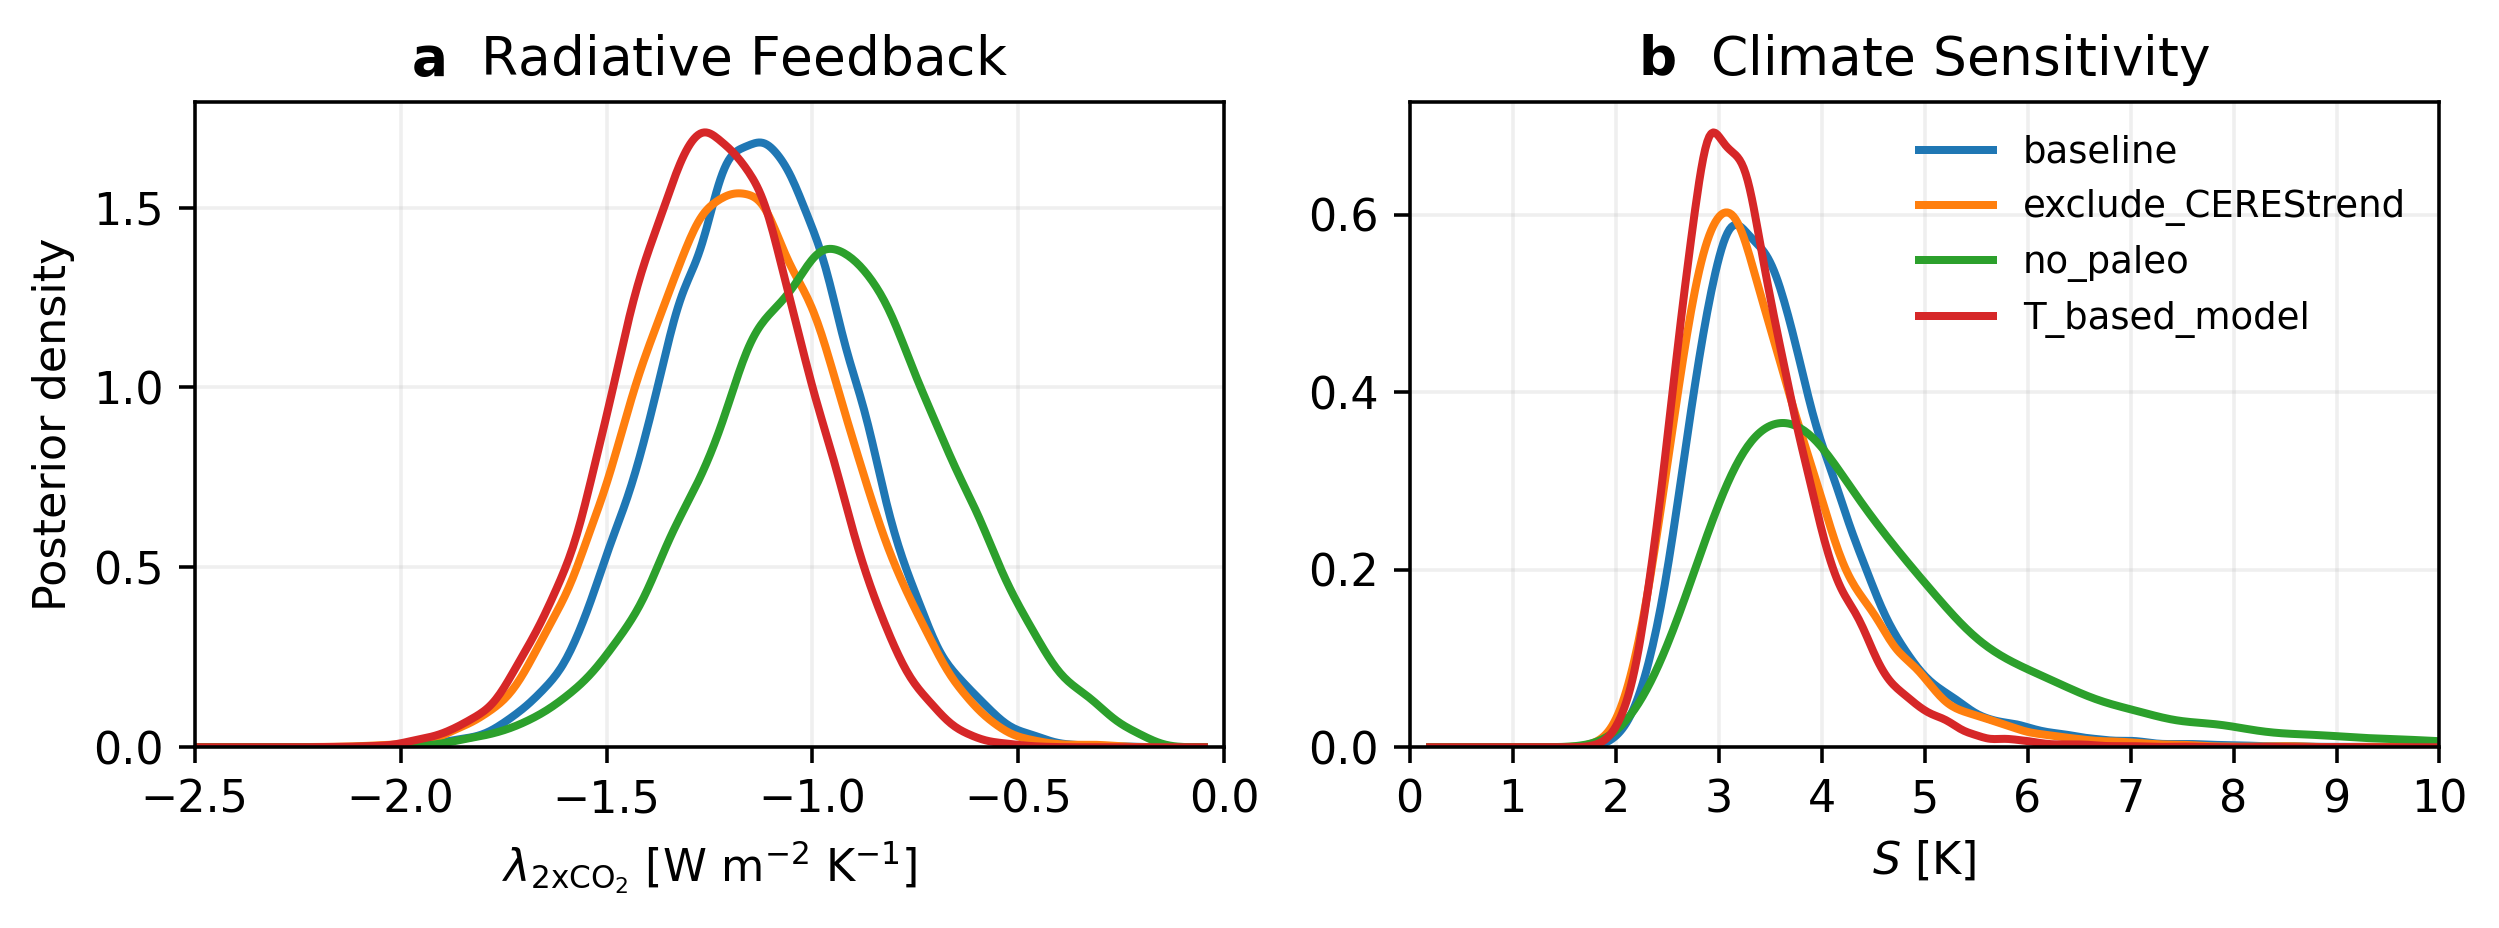

In [18]:
## Note: increase 'iter_sampling' as described above to reduce noise in the PDF estimates

## Plot lambda and ECS posterior densities for every completed scenario.
posterior_lambda_grid = np.linspace(-2.5, -0.05, 500)
posterior_S_grid = np.linspace(0.2, 10.0, 500)

if results:
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160*2)
    for name, entry in results.items():
        axs[0].plot(
            posterior_lambda_grid,
            gaussian_kde(entry["lamb"])(posterior_lambda_grid),
            lw=1.8, label=name,
        )
        axs[1].plot(
            posterior_S_grid,
            gaussian_kde(entry["S"])(posterior_S_grid),
            lw=1.8, label=name,
        )

    axs[0].set(
        xlabel=r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Posterior density",
        xlim=posterior_lambda_grid[[0, -1]],
        title=r"$\mathbf{a}$  Radiative Feedback",
    )
    axs[1].set(
        xlabel=r"$S$ [K]",
        xlim=posterior_S_grid[[0, -1]],
        title=r"$\mathbf{b}$  Climate Sensitivity",
    )
    for ax in axs:
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2)
        ## ax.set_title(ax.get_title(), loc="left")
    axs[1].legend(frameon=False, fontsize="small")

    axs[0].set_xlim(-2.5,0)
    axs[1].set_xlim(0,10)
    axs[1].set_xticks(np.arange(0,10+1,1))
    plt.tight_layout()
    plt.show()

## Likelihoods: visualizing each line of evidence

These diagnostics visualize the same selectable $N$-based or $T$-based convention and nuisance distributions as the Stan model. They are illustrative: Stan samples the joint posterior directly rather than constructing it by multiplying separately calculated likelihoods. Set `score_T=True` in `calculate_likelihoods` to show the score-$T$ convention.

Each likelihood is normalized to its own maximum. The $S$ likelihood are calculated directly as $L(\mathrm{data}\mid S)$ while marginalizing the assessed $F_{2\times CO_2}$ uncertainty, so these are not transformed PDFs and receive no Jacobian. Joint paleo averages the product of the LGM and Pliocene contributions using shared $F_{2\times CO_2}$ draws and correlated paleo pattern-effect draws. Joint Historical–Trend evaluates the two budget residuals together using their shared $F_{2\times CO_2}$ draw and the assessed cross-period aerosol and residual-other forcing covariances. Neither joint curve is formed by multiplying separately marginalized curves.


In [12]:
likelihood_defaults = {
    ## Quick, smooth defaults; increase mc_draws/grid_points for publication.
    "lambda_min": -4.0,
    "lambda_max": -0.005,
    "S_min": 0.05,
    "S_max": 10.0,
    "grid_points": 260,
    "mc_draws": 30_000,
    "seed": 20250813,
}

individual_evidence = ("Process", "Historical", "Trend", "LGM", "Pliocene")
hist_trend_evidence = ("Historical", "Trend", "Joint Historical + Trend")
paleo_evidence = ("LGM", "Pliocene", "Joint paleo")
proc_hist_paleo_evidence = ("Process", "Joint Historical + Trend", "Joint paleo")

likelihood_styles = {
    "Process": dict(color="navy", ls="-"),
    "Historical": dict(color="forestgreen", ls=":"),
    "Trend": dict(color="forestgreen", ls="--"),
    "Joint Historical + Trend": dict(color="darkgreen", ls="-"),
    "LGM": dict(color="royalblue", ls="-"),
    "Pliocene": dict(color="darkorange", ls="-"),
    "Joint paleo": dict(color="firebrick", ls="-"),
}


def _relative_likelihood(values):
    values = np.asarray(values, dtype=float)
    peak = np.nanmax(values)
    if not np.isfinite(peak) or peak <= 0:
        raise ValueError("Likelihood curve has no finite positive values")
    return values / peak


def _normal_density_from_variance(observed, predicted_mean, variance):
    variance = np.maximum(np.asarray(variance, dtype=float), 1e-14)
    return np.exp(-0.5 * (observed - predicted_mean)**2 / variance) / np.sqrt(
        2 * np.pi * variance
    )


def _bivariate_normal_density_from_covariance(
    residual_x, residual_y, variance_x, variance_y, covariance_xy,
):
    """Evaluate a zero-mean bivariate-normal density from residuals."""
    variance_x = np.asarray(variance_x, dtype=float)
    variance_y = np.asarray(variance_y, dtype=float)
    determinant = variance_x * variance_y - covariance_xy**2
    if np.any(determinant <= 0):
        raise ValueError("Joint Historical/Trend covariance is not positive definite")
    quadratic = (
        variance_y * residual_x**2
        - 2 * covariance_xy * residual_x * residual_y
        + variance_x * residual_y**2
    ) / determinant
    return np.exp(-0.5 * quadratic) / (2 * np.pi * np.sqrt(determinant))


def _meinshausen_co2_sarf(co2_ppm, n2o_ppb=273.0):
    co2_ppm = np.asarray(co2_ppm, dtype=float)
    a1, b1, c1, d1 = -2.4785e-7, 7.5906e-4, -2.1492e-3, 5.2488
    co2_ref = 277.15
    co2_alpha_max = co2_ref - b1 / (2 * a1)
    alpha_prime = np.where(
        co2_ppm <= co2_ref,
        d1,
        np.where(
            co2_ppm < co2_alpha_max,
            d1 + a1 * (co2_ppm - co2_ref)**2 + b1 * (co2_ppm - co2_ref),
            d1 - b1**2 / (4 * a1),
        ),
    )
    return (alpha_prime + c1 * np.sqrt(n2o_ppb)) * np.log(co2_ppm / co2_ref)


def _plio_co2_f2x_ratio(co2_ppm, co2_pi):
    return (
        _meinshausen_co2_sarf(co2_ppm) - _meinshausen_co2_sarf(co2_pi)
    ) / (
        _meinshausen_co2_sarf(2 * co2_pi) - _meinshausen_co2_sarf(co2_pi)
    )

In [13]:
def calculate_likelihoods(
    label="baseline", *, input_updates=None, settings_updates=None,
    process_correlation=False, score_T=False,
):
    """Calculate marginal likelihoods on lambda and S grids.

    Use input_updates to change assessed parameters for one sensitivity version.
    Use settings_updates to change grids, sample count, or seed.
    Set process_correlation=True to apply rho_lambda_F2x to the Process curve.
    Set score_T=True to rearrange every energy budget and score temperature.
    """
    data = dict(base_inputs)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(f"Unknown likelihood inputs: {sorted(unknown_inputs)}")
    data.update(input_updates)

    settings = dict(likelihood_defaults)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    ## Reuse common draws across every grid point and line of evidence.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    dlambda_hist = skewnorm.rvs(
        a=data["shape_dlambda"], loc=data["loc_dlambda"],
        scale=data["scale_dlambda"], size=n, random_state=rng,
    )
    dlambda_trend = rng.normal(
        data["mu_dlambda_trend"], data["sig_dlambda_trend"], n
    )

    paleo_dlambda_cov = np.array([
        [
            data["sig_dlambda_LGM"]**2,
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
        ],
        [
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
            data["sig_dlambda_plio"]**2,
        ],
    ])
    paleo_dlambda = rng.multivariate_normal(
        [data["mu_dlambda_LGM"], data["mu_dlambda_plio"]],
        paleo_dlambda_cov, size=n,
    )
    dlambda_lgm, dlambda_plio = paleo_dlambda.T
    f_co2_lgm = rng.normal(data["mu_f_CO2_LGM"], data["sig_f_CO2_LGM"], n)
    co2_plio = rng.normal(data["mu_CO2_plio"], data["sig_CO2_plio"], n)
    f_ch4 = rng.normal(data["mu_fCH4"], data["sig_fCH4"], n)
    f_co2_plio = _plio_co2_f2x_ratio(co2_plio, data["CO2_PI"])

    rho_process = data["rho_lambda_F2x"] if process_correlation else 0.0
    if not -1 < rho_process < 1:
        raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    ## Check each assessed Historical-Trend forcing covariance before
    ## combining them in the joint budget-residual likelihood.
    forcing_covariance_components = (
        (
            "anthropogenic aerosol",
            data["sig_F_anthro_aerosol_hist"],
            data["sig_F_anthro_aerosol_trend"],
            data["cov_F_anthro_aerosol_hist_trend"],
        ),
        (
            "residual other",
            data["sig_F_other_hist"],
            data["sig_F_other_trend"],
            data["cov_F_other_hist_trend"],
        ),
    )
    for component, sig_hist, sig_trend, covariance in forcing_covariance_components:
        if abs(covariance) >= sig_hist * sig_trend:
            raise ValueError(
                f"Historical-Trend {component} covariance is not positive definite"
            )
    hist_trend_forcing_covariance = (
        data["cov_F_anthro_aerosol_hist_trend"]
        + data["cov_F_other_hist_trend"]
    )

    hist_forcing_mean = (
        data["mu_F_CO2_hist"] * F2x / data["erf_2x"]
        + data["mu_F_anthro_aerosol_hist"] + data["mu_F_other_hist"]
    )
    hist_forcing_variance = (
        data["sig_F_anthro_aerosol_hist"]**2
        + data["sig_F_other_hist"]**2
    )

    def evaluate_at_lambda(lam, scalar_lambda, S_value=None):
        ## Process: the lambda marginal is unchanged by its F2x correlation.
        if scalar_lambda:
            process_like = norm.pdf(lam, data["mu_lambda"], data["sig_lambda"])
        else:
            ## Exact marginal for lambda = -F2x/S, including optional covariance.
            process_residual_mean = data["mu_lambda"] + data["erf_2x"] / S_value
            process_residual_variance = (
                data["sig_lambda"]**2
                + (data["sig_F2xCO2"] / S_value)**2
                + 2 * rho_process * data["sig_lambda"]
                * data["sig_F2xCO2"] / S_value
            )
            process_like = _normal_density_from_variance(
                0.0, process_residual_mean, process_residual_variance
            )

        beta_hist = lam - dlambda_hist
        hist_response_factor = np.abs(beta_hist) if score_T else 1.0
        hist_mean = hist_forcing_mean + data["mu_T_hist"] * beta_hist
        hist_variance = (
            data["sig_N_hist"]**2 + hist_forcing_variance
            + beta_hist**2 * data["sig_T_hist"]**2
        )
        historical_like = np.mean(
            hist_response_factor * _normal_density_from_variance(
                data["mu_N_hist"], hist_mean, hist_variance
            )
        )

        beta_trend = lam - dlambda_trend
        trend_response_factor = np.abs(beta_trend) if score_T else 1.0
        trend_forcing_mean = (
            data["mu_F_CO2_trend"] * F2x / data["erf_2x"]
            + data["mu_F_anthro_aerosol_trend"]
            + data["mu_F_other_trend"]
        )
        trend_mean = trend_forcing_mean + data["mu_T_trend"] * beta_trend
        trend_variance = (
            data["sig_N_trend"]**2
            + data["sig_F_anthro_aerosol_trend"]**2
            + data["sig_F_other_trend"]**2
            + beta_trend**2 * data["sig_T_trend"]**2
            - 2 * beta_trend * data["cov_TN_trend"]
        )
        trend_like = np.mean(
            trend_response_factor * _normal_density_from_variance(
                data["mu_N_trend"], trend_mean, trend_variance
            )
        )

        ## Integrate the two energy-budget residuals jointly. Shared CO2
        ## forcing uncertainty is represented by the common F2x draw; the
        ## covariance below is only for aerosol plus residual-other forcing.
        joint_hist_trend_density = (
            hist_response_factor * trend_response_factor
            * _bivariate_normal_density_from_covariance(
                data["mu_N_hist"] - hist_mean,
                data["mu_N_trend"] - trend_mean,
                hist_variance,
                trend_variance,
                hist_trend_forcing_covariance,
            )
        )
        joint_hist_trend_like = np.mean(joint_hist_trend_density)

        beta_lgm = lam - dlambda_lgm
        lgm_response_factor = np.abs(beta_lgm) if score_T else 1.0
        lgm_mean = (
            data["mu_F_other_LGM"] + f_co2_lgm * F2x
            + data["mu_T_LGM"] * beta_lgm
        )
        lgm_variance = (
            data["sig_N_LGM"]**2 + data["sig_F_other_LGM"]**2
            + beta_lgm**2 * data["sig_T_LGM"]**2
        )
        lgm_density = lgm_response_factor * _normal_density_from_variance(
            data["mu_N_LGM"], lgm_mean, lgm_variance
        )

        beta_plio = lam - dlambda_plio
        plio_response_factor = np.abs(beta_plio) if score_T else 1.0
        plio_mean = (
            f_co2_plio * F2x * (1 + f_ch4)
            + data["mu_F_plio_nonGHG"]
            + data["mu_T_plio"] * beta_plio
        )
        plio_variance = (
            data["sig_N_plio"]**2 + data["sig_F_plio_nonGHG"]**2
            + beta_plio**2 * data["sig_T_plio"]**2
        )
        plio_density = plio_response_factor * _normal_density_from_variance(
            data["mu_N_plio"], plio_mean, plio_variance
        )

        return {
            "Process": process_like,
            "Historical": historical_like,
            "Trend": trend_like,
            "Joint Historical + Trend": joint_hist_trend_like,
            "LGM": np.mean(lgm_density),
            "Pliocene": np.mean(plio_density),
            ## Calculate this jointly rather than multiplying separately marginalized curves.
            "Joint paleo": np.mean(lgm_density * plio_density),
        }

    raw = {
        name: {"lambda": [], "S": []}
        for name in (*individual_evidence, "Joint Historical + Trend", "Joint paleo")
    }
    for lam in lambda_grid:
        evaluated = evaluate_at_lambda(lam, scalar_lambda=True)
        for name, value in evaluated.items():
            raw[name]["lambda"].append(value)
    for S in S_grid:
        evaluated = evaluate_at_lambda(-F2x / S, scalar_lambda=False, S_value=S)
        for name, value in evaluated.items():
            raw[name]["S"].append(value)

    curves = {
        name: {
            axis: _relative_likelihood(values)
            for axis, values in axis_values.items()
        }
        for name, axis_values in raw.items()
    }
    return {
        "label": label, "data": data, "settings": settings,
        "process_correlation": process_correlation,
        "score_T": score_T,
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw,
    }

In [14]:
def _format_likelihood_axes(axs, lambda_grid, S_grid, legend=True):
    axs[0].set(
        xlabel=r"$\lambda$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Relative likelihood", xlim=(-4,0),
        title=r"$\mathbf{a}$  Radiative Feedback",
    )
    axs[1].set(
        xlabel=r"$S$ [K]", xlim=(0,10),
        title=r"$\mathbf{b}$  Climate Sensitivity",
    )
    for ax in axs:
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)
        ## ax.set_title(ax.get_title(), loc="left")
    if legend:
        axs[0].legend(frameon=False, fontsize="small")


def plot_likelihoods(result, evidence=individual_evidence, *, title=None, save=None):
    """Plot selected evidence curves from one likelihood calculation."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    for name in evidence:
        style = likelihood_styles.get(name, {})
        axs[0].plot(
            result["lambda_grid"], result["curves"][name]["lambda"],
            lw=1.8, label=name, **style,
        )
        axs[1].plot(
            result["S_grid"], result["curves"][name]["S"],
            lw=1.8, label=name, **style,
        )
    _format_likelihood_axes(axs, result["lambda_grid"], result["S_grid"])
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    return fig, axs


def plot_likelihood_versions(versions, evidence, *, title=None, save=None):
    """Overlay one line of evidence from several sensitivity versions."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    for label, result in versions.items():
        axs[0].plot(
            result["lambda_grid"], result["curves"][evidence]["lambda"],
            lw=1.8, label=label,
        )
        axs[1].plot(
            result["S_grid"], result["curves"][evidence]["S"],
            lw=1.8, label=label,
        )
    first = next(iter(versions.values()))
    _format_likelihood_axes(axs, first["lambda_grid"], first["S_grid"])
    if title is None:
        title = f"{evidence} likelihood sensitivity"
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    return fig, axs


def calculate_process_only_posterior(
    result, *, lambda_prior_bounds=(-20.0, -0.01),
    process_correlation=False, forcing_grid_points=2_000,
):
    """Process-only posterior PDF for S under a fixed uniform-lambda prior.

    The Process likelihood and F2x assessment are combined in (F2x, lambda)
    space, then transformed to S=-F2x/lambda with the required F2x/S**2
    Jacobian. The returned S curve is an area-normalized PDF, not a
    peak-normalized likelihood.
    """
    data = result["data"]
    lambda_lower, lambda_upper = map(float, lambda_prior_bounds)
    if not lambda_lower < lambda_upper < 0:
        raise ValueError("lambda_prior_bounds must satisfy lower < upper < 0")

    rho = data["rho_lambda_F2x"] if process_correlation else 0.0
    if not -1 < rho < 1:
        raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    mu_F, sig_F = data["erf_2x"], data["sig_F2xCO2"]
    mu_lamb, sig_lamb = data["mu_lambda"], data["sig_lambda"]
    F_grid = np.linspace(
        max(1e-8, mu_F - 8 * sig_F),
        mu_F + 8 * sig_F,
        int(forcing_grid_points),
    )
    F_density = norm.pdf(F_grid, mu_F, sig_F)

    ## Conditional lambda distribution implied by the optional bivariate
    ## Gaussian Process/F2x assessment. With rho=0 this reduces to the
    ## independent Process likelihood used by the baseline.
    conditional_lamb_mean = (
        mu_lamb + rho * sig_lamb / sig_F * (F_grid - mu_F)
    )
    conditional_lamb_sd = sig_lamb * np.sqrt(1 - rho**2)
    prior_interval_mass = (
        norm.cdf((lambda_upper - conditional_lamb_mean) / conditional_lamb_sd)
        - norm.cdf((lambda_lower - conditional_lamb_mean) / conditional_lamb_sd)
    )
    joint_normalization = np.trapz(
        F_density * prior_interval_mass, F_grid
    )

    S_grid = result["S_grid"]
    lamb_at_S = -F_grid[None, :] / S_grid[:, None]
    lamb_density_given_F = norm.pdf(
        (lamb_at_S - conditional_lamb_mean[None, :])
        / conditional_lamb_sd
    ) / conditional_lamb_sd
    inside_prior = (
        (lamb_at_S >= lambda_lower) & (lamb_at_S <= lambda_upper)
    )
    transformed_joint = (
        F_density[None, :] * lamb_density_given_F * inside_prior
        * F_grid[None, :] / S_grid[:, None]**2
    )
    S_pdf = np.trapz(transformed_joint, F_grid, axis=1) / joint_normalization

    lambda_likelihood = norm.pdf(
        result["lambda_grid"], mu_lamb, sig_lamb
    )
    return {
        "lambda_grid": result["lambda_grid"],
        "lambda_likelihood": _relative_likelihood(lambda_likelihood),
        "S_grid": S_grid,
        "S_pdf": S_pdf,
        "lambda_prior_bounds": (lambda_lower, lambda_upper),
        "process_correlation": process_correlation,
    }


def plot_process_likelihood_and_posterior(
    process_result, *, title="Process evidence", save=None,
):
    """Plot L(Process | lambda) and the process-only posterior PDF of S."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    style = likelihood_styles["Process"]
    axs[0].plot(
        process_result["lambda_grid"],
        process_result["lambda_likelihood"],
        lw=1.8, **style,
    )
    axs[1].plot(
        process_result["S_grid"], process_result["S_pdf"],
        lw=1.8, **style,
    )

    axs[0].set(
        xlabel=r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Relative likelihood", xlim=(-4, 0), ylim=(0, 1.05),
        title=r"$\mathbf{a}$  Process likelihood",
    )
    axs[1].set(
        xlabel=r"$S$ [K]", ylabel=r"Posterior density [K$^{-1}$]",
        xlim=(0, 10), ylim=(0, None),
        title=r"$\mathbf{b}$  Process-only posterior",
    )
    for ax in axs:
        ax.grid(alpha=0.2)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    return fig, axs

### Baseline likelihood calculation

All five individual diagnostics are calculated whether or not a particular line is enabled in a Stan scenario.

Revised N-based likelihoods


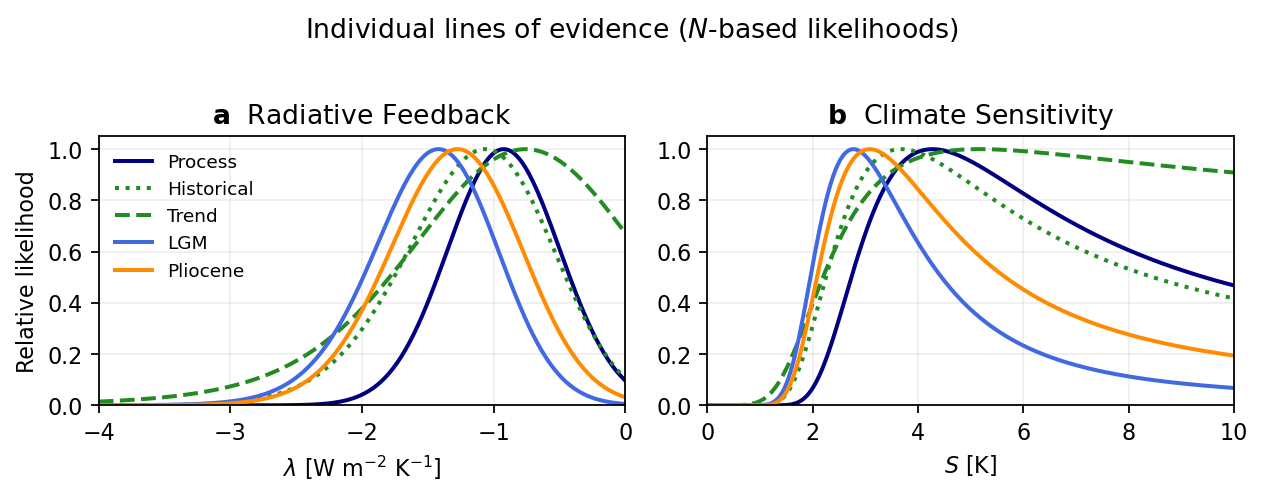

SW20 T-based likelihoods


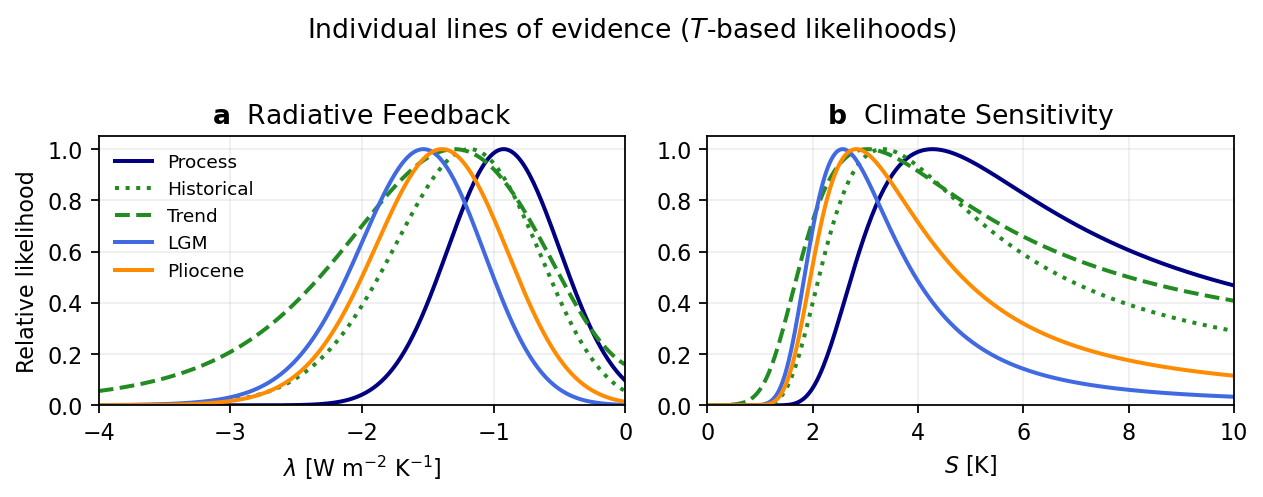

In [15]:
print('Revised N-based likelihoods')
## Baseline (N-based)
likelihood_results = {}
likelihood_results["baseline"] = calculate_likelihoods(
    "baseline",
    score_T=0,
)

plot_likelihoods(
    likelihood_results["baseline"],
    evidence=individual_evidence,
    title="Individual lines of evidence ($N$-based likelihoods)",
)
plt.show()

print('SW20 T-based likelihoods')
## T-based version
likelihood_results_scoreT = {}
likelihood_results_scoreT["baseline"] = calculate_likelihoods(
    "baseline",
    score_T=1,
)
plot_likelihoods(
    likelihood_results_scoreT["baseline"],
    evidence=individual_evidence,
    title="Individual lines of evidence ($T$-based likelihoods)",
)
plt.show()

## Process likelihood and process-only posterior

The left panel retains the Process likelihood in $\lambda$ space. The right panel shows the normalized posterior PDF of $S=-F_{2\times CO_2}/\lambda$ using only the Process evidence and the assessed $F_{2\times CO_2}$ distribution, with a fixed uniform prior over $-20 < \lambda < -0.01$ W m$^{-2}$ K$^{-1}$. The transformation includes the required $F_{2\times CO_2}/S^2$ Jacobian.

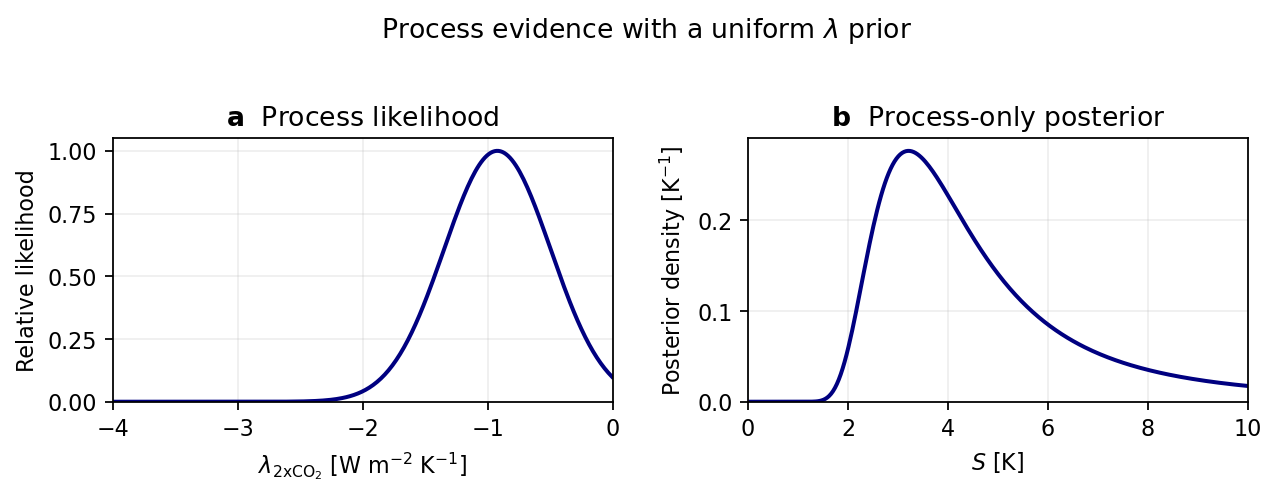

In [16]:
process_only_posterior = calculate_process_only_posterior(
    likelihood_results["baseline"],
    lambda_prior_bounds=(-20.0, -0.01),
    process_correlation=bool(
        baseline_switches["use_lambda_F2x_correlation"]
    ),
)

plot_process_likelihood_and_posterior(
    process_only_posterior,
    title=r"Process evidence with a uniform $\lambda$ prior",
)
plt.show()

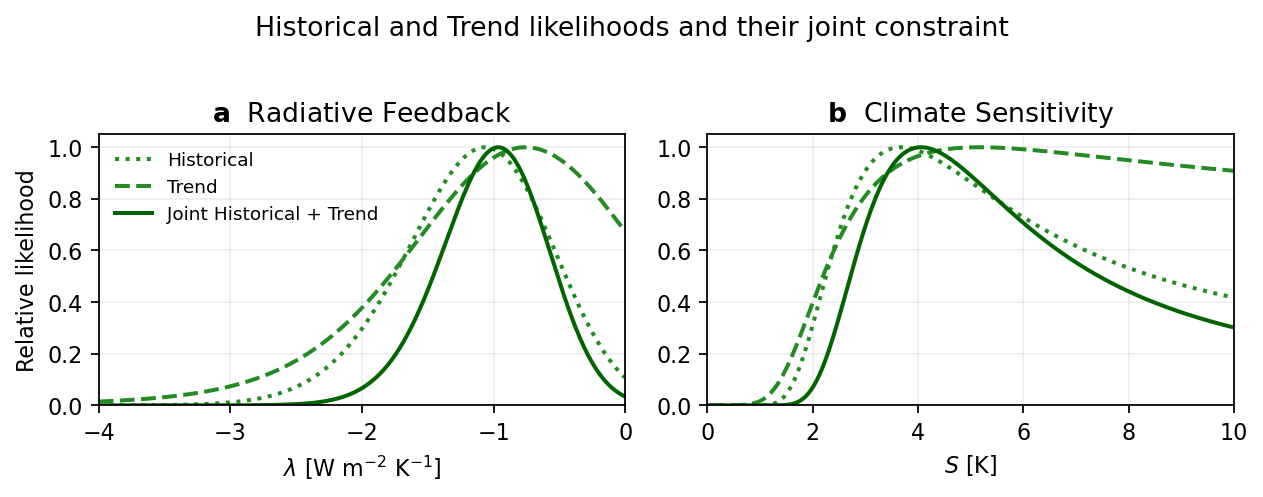

In [17]:
## Joint Historical + Trend uses shared F_2xCO2 draws and the assessed
## cross-period aerosol and residual-other forcing covariances. It is not
## the product of the separately marginalized Historical and Trend curves.
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=hist_trend_evidence,
    title="Historical and Trend likelihoods and their joint constraint",
)
plt.show()

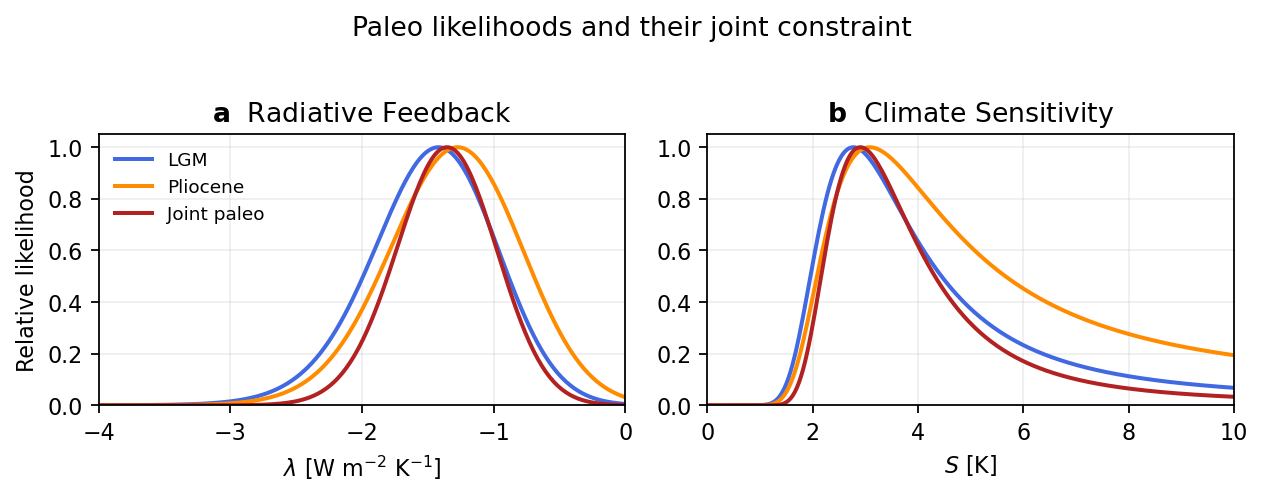

In [18]:
## Calculate Joint paleo with shared F_2xCO2 draws and the assessed
## LGM-Pliocene pattern-effect correlation. It is not L_LGM * L_Pliocene.
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=paleo_evidence,
    title="Paleo likelihoods and their joint constraint",
)
plt.show()

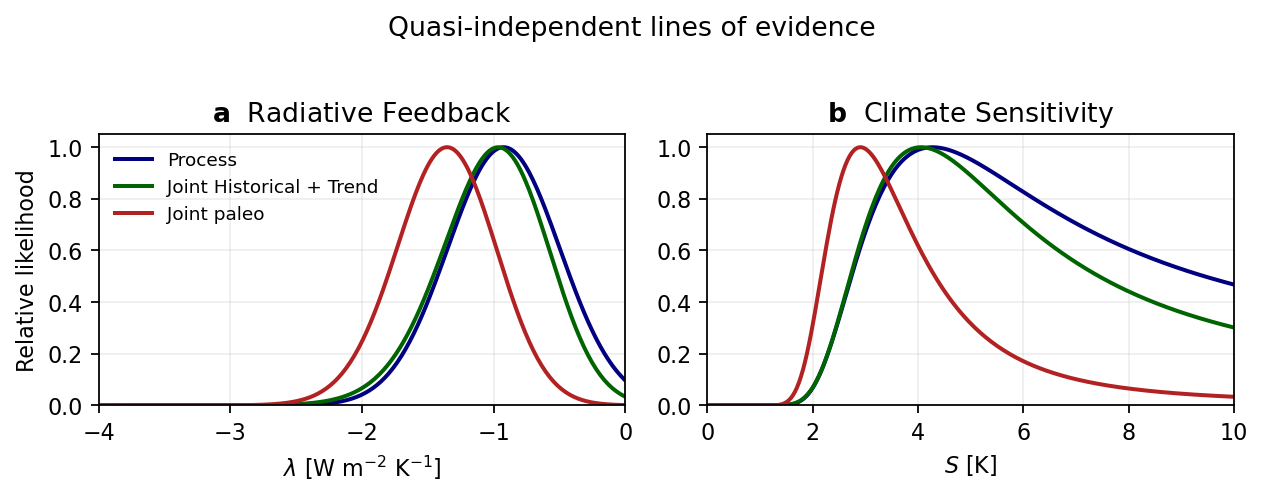

In [19]:
## three quasi-independent lines of evidence
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=proc_hist_paleo_evidence,
    title="Quasi-independent lines of evidence",
)
plt.show()

## Process-feedback component assessment

The blue points are constructed directly from the process-feedback inputs at the top of the notebook, so changing those inputs and rerunning this cell updates the figure. The Planck feedback is plotted after adding 2 W m$^{-2}$ K$^{-1}$, as indicated on its axis label. Thick and thin intervals show central 66% and 90% Gaussian ranges.


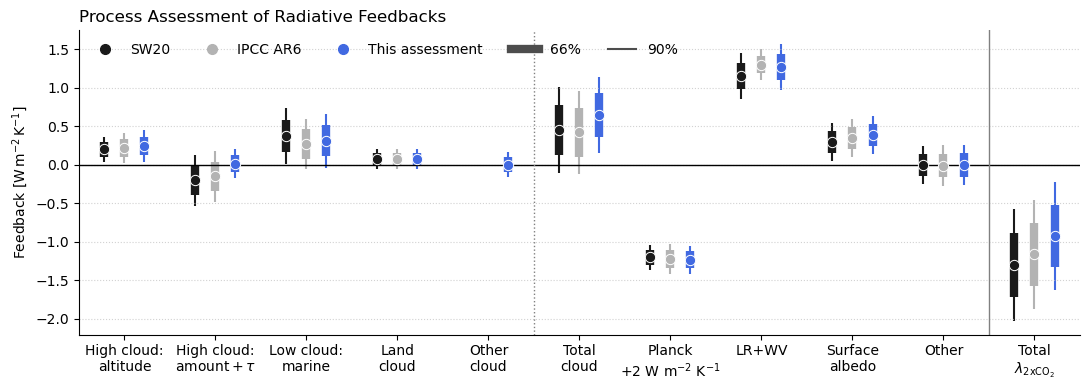

In [20]:
from matplotlib import ticker
from matplotlib.lines import Line2D

## Feedback order follows the current assessment table.
process_feedbacks = [
    "High cloud:\naltitude",
    "High cloud:\n" + r"$\mathrm{amount} + \tau$",
    "Low cloud:\nmarine",
    "Land\ncloud",
    "Other\ncloud",
    "Total\ncloud",
    "Planck\n" + r"$+2$ W m$^{-2}$ K$^{-1}$",
    "LR+WV",
    "Surface\nalbedo",
    "Other",
    "Total\n" + r"$\lambda_\mathrm{2xCO_2}$",
]

process_assessments = {
    "SW20": {
        "mean": [0.20, -0.20, 0.37, 0.08, np.nan, 0.45,
                 2 - 3.20, 1.15, 0.30, 0.00, -1.30],
        "sigma": [0.10, 0.20, 0.22, 0.08, np.nan, 0.34,
                  0.10, 0.18, 0.15, 0.15, 0.44],
        "color": "0.1",
    },
    "IPCC AR6": {
        "mean": [0.22, -0.15, 0.27, 0.08, np.nan, 0.42,
                 2 - 3.22, 1.30, 0.35, -0.01, -1.16],
        "sigma": [0.12, 0.20, 0.20, 0.08, np.nan, 0.33,
                  0.12, 0.12, 0.15, 0.16, 0.43],
        "color": "0.7",
    },
    "This assessment": {
        ## These values all refer back to the assessed inputs above.
        "mean": [
            highcloud_alt_mu,
            highcloud_amt_optdepth_mu,
            marine_lowcloud_mu,
            landcloud_mu,
            unassessed_cloud_mu,
            cloud_total_mu,
            2 + planck_mu,
            lrwv_mu,
            surface_albedo_mu,
            unassessed_noncloud_mu,
            process_lamb_mu,
        ],
        "sigma": [
            highcloud_alt_sig,
            highcloud_amt_optdepth_sig,
            marine_lowcloud_sig,
            landcloud_sig,
            unassessed_cloud_sig,
            cloud_total_sig,
            planck_sig,
            lrwv_sig,
            surface_albedo_sig,
            unassessed_noncloud_sig,
            process_lamb_sig,
        ],
        "color": "royalblue",
    },
}

z66 = 0.954
z90 = 1.645
x = np.arange(len(process_feedbacks))
offsets = [-0.22, 0.0, 0.22]

fig, ax = plt.subplots(figsize=(11, 4))

for offset, (name, values) in zip(offsets, process_assessments.items()):
    mean = np.asarray(values["mean"], dtype=float)
    sigma = np.asarray(values["sigma"], dtype=float)
    xpos = x + offset
    mask = np.isfinite(mean) & np.isfinite(sigma)

    ax.vlines(
        xpos[mask], mean[mask] - z90 * sigma[mask],
        mean[mask] + z90 * sigma[mask],
        color=values["color"], linewidth=1.5, zorder=1,
    )
    ax.vlines(
        xpos[mask], mean[mask] - z66 * sigma[mask],
        mean[mask] + z66 * sigma[mask],
        color=values["color"], linewidth=6, zorder=2,
    )
    ax.scatter(
        xpos[mask], mean[mask], color=values["color"], edgecolor="white",
        linewidth=0.7, s=55, zorder=3,
    )

ax.axhline(0, color="black", linewidth=1)
ax.axvline(4.5, color="0.5", linestyle=":", linewidth=1)
ax.axvline(9.5, color="0.5", linewidth=1)
ax.set_xlim(-0.5, len(process_feedbacks) - 0.5)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.grid(axis="y", linestyle=":", color="0.75", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(process_feedbacks)
ax.set_ylabel(r"Feedback $[\mathrm{W\,m^{-2}\,K^{-1}}]$")
ax.set_title("Process Assessment of Radiative Feedbacks", loc="left")

legend_items = [
    Line2D(
        [0], [0], marker="o", linestyle="none", color=values["color"],
        markersize=7, label=name,
    )
    for name, values in process_assessments.items()
] + [
    Line2D([0], [0], color="0.3", linewidth=6, label="66%"),
    Line2D([0], [0], color="0.3", linewidth=1.5, label="90%"),
]
ax.legend(handles=legend_items, ncol=5, frameon=False, loc="upper left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()
